This notebook trains models using clean and noisy audio files. It use two 'types' of noise sources:
- Colored and general noise sources: "white","pink","babble","kitchen","office","living"
- Specific noise sources: "car_horn_background","dog_bark_foreground","street_music_foreground"

The proposed model is based on the full precision model from the paper "Sub-mW Keyword Spotting on an MCU: Analog Binary Feature Extration and Bynary Neural Networks" by Cerutti et al. (2022) published on IEEE Transactions on Circuits and Systems.
The proposed model append a fully connected layer to the paper's model structure.

The goals are:
1) Test the proposed model with the general noise source (baseline).
2) Improve the generalization of the baseline model training it again with general noise sources (noise-aware model).
3) Compare the performance of the baseline vs the noise-aware model under general noise sources.
4) Test the baseline and noise-aware models in specific noise sources.
5) Using active learning in both models to improve the performance.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import multiprocessing as mp
from functools import partial
from scipy import stats
from scipy.stats import wilcoxon
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib as mpl
import seaborn as sns
import param
from utils import *
from scipy.stats import friedmanchisquare
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

--2025-08-19 15:51:47--  https://raw.githubusercontent.com/lucianomrau/Use_SpeechCommandDatasetV2_properly/refs/heads/master/speech_command_dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10244 (10K) [text/plain]
Saving to: ‘speech_command_dataset.py’

     0K ..........                                            100% 10.2M=0.001s

2025-08-19 15:51:48 (10.2 MB/s) - ‘speech_command_dataset.py’ saved [10244/10244]



In [9]:
from functions.spectrogram import SpectrogramSpeechCommandDataset
from functions.add_noise import AddNoise
import torch, torchaudio
from torch.utils.data import DataLoader, TensorDataset,ConcatDataset
from torchsummary import summary
from functions.torchModel import train_model, test_model_accuracy,test_model_with_confusion_matrix
from functions.ModelsArchitecture import ConvNet,ConvNetWithFC
from utils import test_model_parallel,create_balanced_subset,load_in_memory, create_subsets,add_noise_on_set

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

reset_seed()

Using device: cuda


# Load noiseless data

In [10]:
mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            n_mels = param.N_MELS,
            n_fft = param.N_FFT, 
            hop_length = param.HOP_LENGTH,
            win_length = param.WIN_LENGTH,
            f_min = param.F_MIN,
            f_max = param.F_MAX,
            power = param.POWER,
            sample_rate = param.SAMPLE_RATE,
        )

dataset = SpectrogramSpeechCommandDataset(
    audio_dataset_path=param.DATASET_PATH,
    audio_test_path=param.TESTSET_PATH,
    transformation=mel_spectrogram,
    sample_rate= param.SAMPLE_RATE,
    duration_seconds = param.DURATION_SEC,
    keywords=param.KEYWORDS,
    device = device
)

## Load audio files

In [11]:
test_set_waveform = dataset.get_testset()
# validation_set_waveform = dataset.get_validationset()
train_set_waveform = dataset.get_trainset()

## MEL Spectrogram

In [12]:
test_set = dataset.get_spectrum_testset()
train_set = dataset.get_spectrum_trainset()
validation_set = dataset.get_spectrum_validationset()

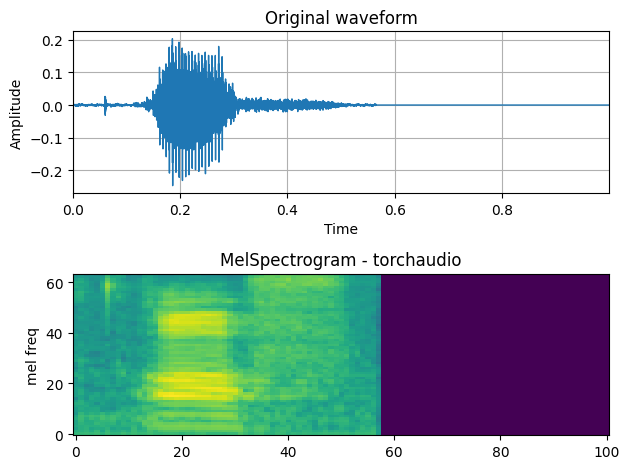

In [13]:
fig, axs = plt.subplots(2, 1)
plot_waveform(train_set_waveform[0][0].cpu(), param.SAMPLE_RATE, title="Original waveform", 
              ax=axs[0],ylabel="Amplitude",xlabel="Time")
plot_spectrogram(train_set[0][0][0].cpu(), ax=axs[1],title="MelSpectrogram - torchaudio", ylabel="mel freq")
fig.tight_layout()

In [14]:
baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
summary(baseline_model,(1,101,64),batch_size = param.BATCH_SIZE)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [16, 64, 51, 32]             640
       BatchNorm2d-2           [16, 64, 51, 32]             128
            Conv2d-3          [16, 128, 51, 32]          73,856
       BatchNorm2d-4          [16, 128, 51, 32]             256
            Conv2d-5          [16, 128, 26, 16]         147,584
       BatchNorm2d-6          [16, 128, 26, 16]             256
            Conv2d-7          [16, 192, 26, 16]         221,376
       BatchNorm2d-8          [16, 192, 26, 16]             384
            Conv2d-9          [16, 192, 26, 16]          37,056
      BatchNorm2d-10          [16, 192, 26, 16]             384
           Conv2d-11           [16, 12, 26, 16]           2,316
      BatchNorm2d-12           [16, 12, 26, 16]              24
AdaptiveAvgPool2d-13             [16, 12, 1, 1]               0
          ConvNet-14                   

In [15]:
noise_list = ["white","pink","babble","kitchen","office","living"]
noise_proportion = [20,40,60,80,100]
noise_level = [24,21,18,15,12,9,6,3,0,-3]

# Goal 1: train and test baseline model

Train the proposed model

In [16]:
all_data , all_labels = load_in_memory(train_set)
train_tensor = TensorDataset(torch.stack(all_data) ,torch.tensor(all_labels) )
all_data , all_labels = load_in_memory(validation_set)
val_tensor = TensorDataset(torch.stack(all_data) ,torch.tensor(all_labels) )
all_data , all_labels = load_in_memory(test_set)
test_tensor = TensorDataset(torch.stack(all_data) ,torch.tensor(all_labels) )

train_loader = DataLoader(train_tensor, batch_size = param.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size = param.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size = param.BATCH_SIZE, shuffle=False)

del all_data , all_labels,train_tensor,test_tensor,val_tensor

In [ ]:
# Train a model using the default seed. It will be used for continuous learning.
train_model(train_loader, val_loader, baseline_model,device,param.LEARNING_RATE,num_epochs=50)
torch.save(baseline_model.state_dict(), "./models/baseline_model.pth")

# Train multiple models using different seeds
for current_seed in range(param.NUM_MODELS):
    print(f"\n=== Training Model {current_seed+1}/{param.NUM_MODELS} ===")

    set_seed(current_seed)

    baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
    
    train_model(train_loader, val_loader, baseline_model,device,param.LEARNING_RATE,num_epochs=param.EPOCHS)
    torch.save(baseline_model.state_dict(), f"./models/baseline_model_seed_{current_seed}.pth")


=== Training Model 1/25 ===

=== Training Model 2/25 ===

=== Training Model 3/25 ===

=== Training Model 4/25 ===

=== Training Model 5/25 ===

=== Training Model 6/25 ===

=== Training Model 7/25 ===

=== Training Model 8/25 ===

=== Training Model 9/25 ===

=== Training Model 10/25 ===

=== Training Model 11/25 ===

=== Training Model 12/25 ===

=== Training Model 13/25 ===

=== Training Model 14/25 ===

=== Training Model 15/25 ===

=== Training Model 16/25 ===

=== Training Model 17/25 ===

=== Training Model 18/25 ===

=== Training Model 19/25 ===

=== Training Model 20/25 ===

=== Training Model 21/25 ===

=== Training Model 22/25 ===

=== Training Model 23/25 ===

=== Training Model 24/25 ===

=== Training Model 25/25 ===


### Test without noise

Test Accuracy: 0.9634


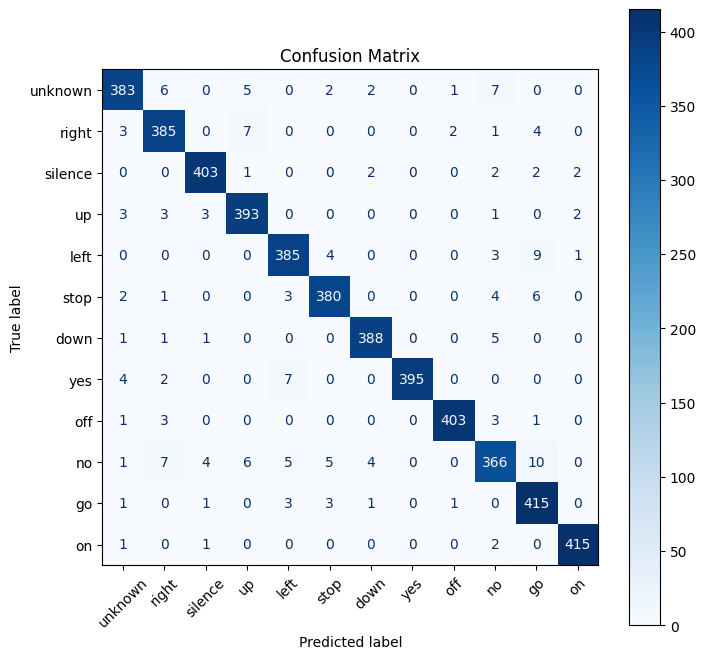

In [17]:
baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
baseline_model.load_state_dict(torch.load(f"./models/baseline_model.pth",weights_only=True))
test_model_with_confusion_matrix(test_loader,baseline_model,param.KEYWORDS,device)

In [ ]:
df_full_precision_train_noiseless_test_all_cases = pd.DataFrame()

print("Performance in models trained with different seeds:")
for current_seed in range(param.NUM_MODELS):
    baseline_model.load_state_dict(torch.load(f"./models/baseline_model_seed_{current_seed}.pth",weights_only=True))
    accuracy,_,_ = test_model_accuracy(test_loader,baseline_model,device)

    print(f'seed: {current_seed} - Accuracy: {accuracy}')
    
    temp_df = pd.DataFrame({
        "seed": current_seed,
        "noise_snr": None,
        "noise_test": "Noiseless",
        "accuracy": accuracy
        },index=[0])
    
    df_full_precision_train_noiseless_test_all_cases = pd.concat([df_full_precision_train_noiseless_test_all_cases ,temp_df], ignore_index=True)

seed: 0 - Accuracy: 0.9621676891615542
seed: 1 - Accuracy: 0.9623721881390593
seed: 2 - Accuracy: 0.9613496932515337
seed: 3 - Accuracy: 0.9644171779141104
seed: 4 - Accuracy: 0.9611451942740287
seed: 5 - Accuracy: 0.9623721881390593
seed: 6 - Accuracy: 0.9609406952965235
seed: 7 - Accuracy: 0.96359918200409
seed: 8 - Accuracy: 0.9623721881390593
seed: 9 - Accuracy: 0.961758691206544
seed: 10 - Accuracy: 0.9615541922290388
seed: 11 - Accuracy: 0.9638036809815951
seed: 12 - Accuracy: 0.9652351738241309
seed: 13 - Accuracy: 0.9625766871165644
seed: 14 - Accuracy: 0.9660531697341513
seed: 15 - Accuracy: 0.96359918200409
seed: 16 - Accuracy: 0.9613496932515337
seed: 17 - Accuracy: 0.9621676891615542
seed: 18 - Accuracy: 0.9650306748466257
seed: 19 - Accuracy: 0.9621676891615542
seed: 20 - Accuracy: 0.9621676891615542
seed: 21 - Accuracy: 0.9595092024539877
seed: 22 - Accuracy: 0.9656441717791411
seed: 23 - Accuracy: 0.9625766871165644
seed: 24 - Accuracy: 0.9621676891615542


In [ ]:
print(f"average accuracy across seeds: {df_full_precision_train_noiseless_test_all_cases["accuracy"].mean()}")

average accuracy: 0.9627239263803681


### Test with noise

In [ ]:
for noise_snr in noise_level:
    for noise_name_test in noise_list:
        test_set_noisy = AddNoise(noise_type=noise_name_test,snr_db=noise_snr,
                                            transformation=mel_spectrogram,device=device,
                                            sample_rate = param.SAMPLE_RATE, 
                                            duration_seconds = param.DURATION_SEC,
                                            dataset=test_set_waveform,
                                            target_set='test')
        
        all_data , all_labels = load_in_memory(test_set_noisy)
        test_tensor = TensorDataset(torch.stack(all_data) ,torch.tensor(all_labels) )
        test_noisy_loader = DataLoader(test_tensor, batch_size = param.BATCH_SIZE, shuffle=False)

        for current_seed in range(param.NUM_MODELS):
            baseline_model.load_state_dict(torch.load(f"./models/baseline_model_seed_{current_seed}.pth",weights_only=True))
            accuracy, _ , _ = test_model_accuracy(test_noisy_loader, baseline_model, device)
            temp_df = pd.DataFrame({
                "seed": current_seed,
                "noise_test": noise_name_test,
                "noise_snr": noise_snr,
                "accuracy": accuracy
                },index=[0])

            df_full_precision_train_noiseless_test_all_cases = pd.concat([df_full_precision_train_noiseless_test_all_cases ,temp_df], ignore_index=True)

df_full_precision_train_noiseless_test_all_cases.to_csv("./results/full_precision_seed_train_original.csv")

In [ ]:
del test_set_noisy,all_data , all_labels,test_tensor,test_noisy_loader, train_loader
torch.cuda.synchronize()
torch.cuda.empty_cache()

# Goal 2: train and test the noise-aware model with different proportion of noise

## Load noisy data

In [ ]:
"""
If I add 20% of the training samples. I will have in total len(train_set_waveform)*0.2 noisy samples.
There are: len(train_set_waveform)*0.2/len(noise_list) samples for each type of noise, for example, "white".
There are: len(train_set_waveform)*0.2/len(noise_list)/len(noise_level) samples for each type of noise at an specific SNR value, for example, "white" at 24dB.
The total number of subset for each noise_proportion case is the combinations of len(noise_list) * len(noise_level)
"""

# Create the subsets to add noise
sub_trainset_list = []
num_noise_list = len(noise_list)
num_noise_level = len(noise_level)
num_subsets = num_noise_list * num_noise_level

for add_percentage in noise_proportion:
    sub_trainset_list.append( create_subsets(train_set_waveform, desired_subsets=num_subsets,replace=True,percentage=add_percentage / num_subsets) )

# sub_trainset_list is a list of list. sub_trainset_list[0] contains the subsets for noise_proportion[0].

In [ ]:
dic_train_set_noise = {'train_set_noisy': [], 'noise_percentage': []}

for idx in range(len(noise_proportion)):
    dic_train_set_noise["noise_percentage"].append(noise_proportion[idx])
    subset_with_noise = []
    for sub_trainset,noise_snr,noise_name in zip(sub_trainset_list[idx] , noise_level* len(noise_list) , noise_list * len(noise_level)):
        tmp = AddNoise(noise_type=noise_name,snr_db=noise_snr,
                        transformation=mel_spectrogram,device=device,
                        sample_rate = param.SAMPLE_RATE,duration_seconds = param.DURATION_SEC,
                        dataset=sub_trainset,target_set='train')
        subset_with_noise = ConcatDataset([subset_with_noise,tmp])
    dic_train_set_noise["train_set_noisy"].append(subset_with_noise)

del tmp,subset_with_noise, sub_trainset_list
torch.cuda.synchronize()

## Train models using general noise sources

In [ ]:
# Training all the models takes some hours.
# TODO: add an early stop during training for speed up

for train_set_noisy, noise_percentage in zip(dic_train_set_noise['train_set_noisy'],dic_train_set_noise['noise_percentage']):
    final_trainset = ConcatDataset([train_set,train_set_noisy])


    all_data , all_labels = load_in_memory(final_trainset)
    train_tensor = TensorDataset(torch.stack(all_data) ,torch.tensor(all_labels) )
    train_loader = DataLoader(train_tensor, batch_size = param.BATCH_SIZE, shuffle=True)

    # train the models using the default seed. It will be used for continuous learning.
    reset_seed()
    model = ConvNetWithFC(ConvNet().to(device)).to(device)
    train_model(train_loader, val_loader, model,device,param.LEARNING_RATE,num_epochs=param.EPOCHS)
    torch.save(model.state_dict(), "./models/full_precision_"+str(noise_percentage)+".pth")
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # train the models with different seeds
    for current_seed in range(param.NUM_MODELS):
        set_seed(current_seed)

        model = ConvNetWithFC(ConvNet().to(device)).to(device)
        train_model(train_loader, val_loader, model,device,param.LEARNING_RATE,num_epochs=param.EPOCHS)
        torch.save(model.state_dict(), "./models/full_precision_seed_"+str(current_seed)+"_noise_porcentage_"+str(noise_percentage)+".pth")
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    del all_data , all_labels, train_tensor, train_loader,final_trainset, model
    
del dic_train_set_noise, train_set,validation_set

## Test the trained classifiers with all noise sources

In [ ]:
# Run in parallel (multiprocessor)
mp.set_start_method("spawn", force=True)

noise_list = ["white", "pink", "babble", "kitchen", "office", "living"]
model = ConvNetWithFC(ConvNet().to(device)).to(device)

all_data, all_labels = load_in_memory(test_set)
test_tensor = TensorDataset(torch.stack(all_data), torch.tensor(all_labels))
test_loader = DataLoader(test_tensor, batch_size = param.BATCH_SIZE, shuffle=False)

tasks = []

# Noiseless
for noise_percentage in noise_proportion:
    tasks.append((noise_percentage, "Noiseless", None))

# Noisy
for noise_percentage in noise_proportion:
    for noise_name_test in noise_list:
        for noise_snr in noise_level:
            tasks.append((noise_percentage, noise_name_test, noise_snr))

ctx = mp.get_context("spawn")
num_workers = min(mp.cpu_count(), 8)

worker_func = partial(
    test_model_parallel,
    test_loader=test_loader,
    test_set_waveform=test_set_waveform,
    device=device,
    num_models=param.NUM_MODELS,
    mel_spectrogram=mel_spectrogram
)

all_results = []
with ctx.Pool(num_workers) as pool:
    for result_batch in pool.map(worker_func, tasks):
        all_results.extend(result_batch)

df_full_precision_train_noise_test_all_cases = pd.DataFrame(all_results)
df_full_precision_train_noise_test_all_cases.to_csv(
    "./results/full_precision_seed_train_with_noise.csv", index=False
)

In [ ]:
torch.cuda.synchronize()
torch.cuda.empty_cache()

# Goal 3: compare in general noise

### baseline-model tested in noisy data

From here I see how the original model behaves with testing noisy samples

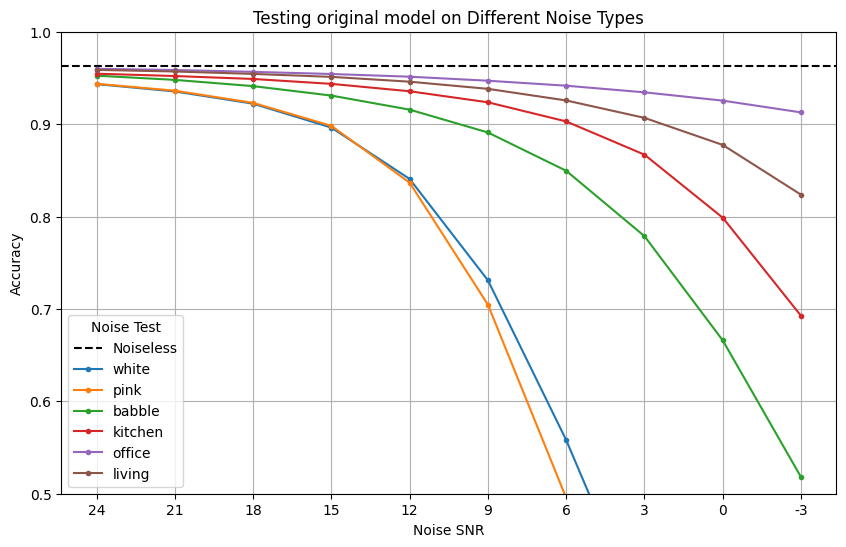

Noiseless average accuracy:  0.9627239263803681


In [ ]:
df_noiseless_train = pd.read_csv('./results/full_precision_seed_train_original.csv')
df_noiseless_train.drop(columns='Unnamed: 0',inplace=True)
df_noiseless_train.drop_duplicates(inplace=True)

noise_test_types = [t for t in df_noiseless_train['noise_test'].unique() if t != 'Noiseless']

plt.figure(figsize=(10, 6))

# First handle the Noiseless case separately (it has no SNR values)
noiseless_data = df_noiseless_train[df_noiseless_train['noise_test'] == 'Noiseless']
baseline = noiseless_data['accuracy'].mean()
plt.axhline(y=baseline, color='black', linestyle='--', label='Noiseless')

# Plot each noise type with average across seeds
for noise_test in noise_test_types:
    subset = df_noiseless_train[df_noiseless_train['noise_test'] == noise_test]
    avg_data = subset.groupby('noise_snr')['accuracy'].mean().reset_index()
    plt.plot(avg_data['noise_snr'], avg_data['accuracy'], label=noise_test, marker=".")

axes = plt.gca()
axes.invert_xaxis()
axes.set_ylim(0.5, 1.0)
min_snr = int(df_noiseless_train['noise_snr'].min())
max_snr = int(df_noiseless_train['noise_snr'].max())
axes.set_xticks(range(min_snr, max_snr+1, 3)) 
axes.set_xticklabels(range(min_snr, max_snr+1, 3))
plt.xlabel('Noise SNR')
plt.ylabel('Accuracy')
plt.title('Testing original model on Different Noise Types')
plt.legend(title='Noise Test')
plt.grid(True)
plt.show()

print("Noiseless average accuracy: ", baseline)

Conclusions: 
- The baseline model perform worse with colored noise sources.
- Lower the SNR, lower the accuracy.

### noise-aware-model tested in noiseless data

In [ ]:
df_noisy_train = pd.read_csv('results/full_precision_seed_train_with_noise.csv')
df_noisy_train_noiseless_test = df_noisy_train[df_noisy_train['noise_test'] == 'Noiseless']
df_noisy_train_noiseless_test.drop(columns=["noise_snr","noise_test"],inplace=True)

print("Porcentual performace decrease [%] regarding the baseline model (train without noise):")
for noise_value in noise_proportion:
    accuracy_values = df_noisy_train_noiseless_test[df_noisy_train_noiseless_test['noise_percentage'] == noise_value]["accuracy"]
    print(f"Noise level: {noise_value} - Accuracy: {accuracy_values.mean()} - Decrease [%]: {(accuracy_values.mean() - baseline)*100}")
    
    statistic, p_value = wilcoxon(noiseless_data['accuracy'], accuracy_values)
    print(f"P-value: {p_value}")

Porcentual performace decrease [%] regarding the baseline model (train without noise):
Noise level: 20 - Accuracy: 0.9604417177914111 - Decrease [%]: -0.2282208588957002
P-value: 0.0002467229859957009
Noise level: 40 - Accuracy: 0.9598364008179959 - Decrease [%]: -0.2887525562372151
P-value: 0.00016201543276462058
Noise level: 60 - Accuracy: 0.959525562372188 - Decrease [%]: -0.3198364008180077
P-value: 3.024132806741821e-05
Noise level: 80 - Accuracy: 0.9581349693251532 - Decrease [%]: -0.4588957055214893
P-value: 1.1920928955078125e-07
Noise level: 100 - Accuracy: 0.9573169734151328 - Decrease [%]: -0.5406952965235301
P-value: 5.960464477539063e-08


/tmp/ipykernel_14321/3991274685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_noisy_train_noiseless_test.drop(columns=["noise_snr","noise_test"],inplace=True)
/home/luciano/virtualenv/python3.8.10/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


Conclusions: 
- More noisy data added for training, more decrease the performance in the noiseless data

### noise-aware-model tested in noisy data

Now, I want to find the models that perform better on the different noise sources.

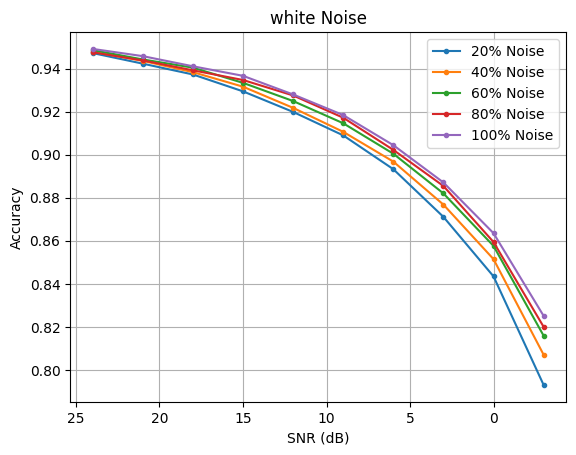

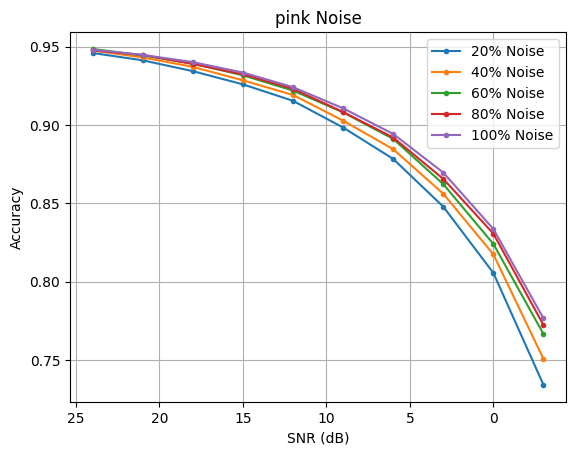

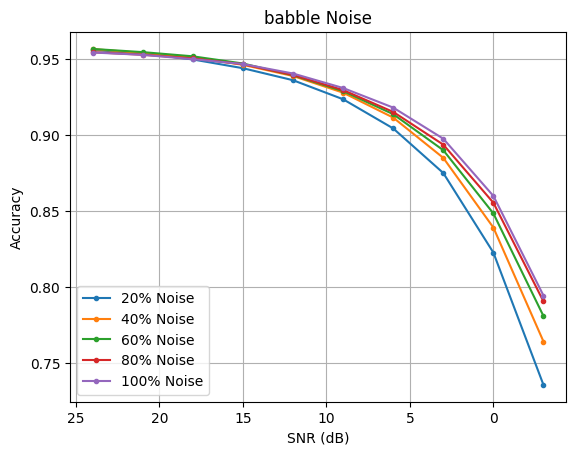

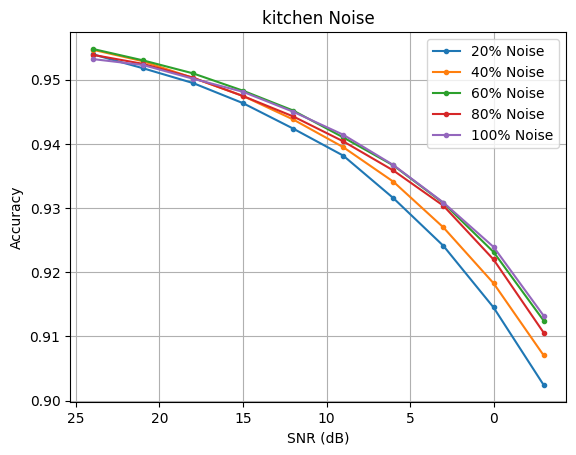

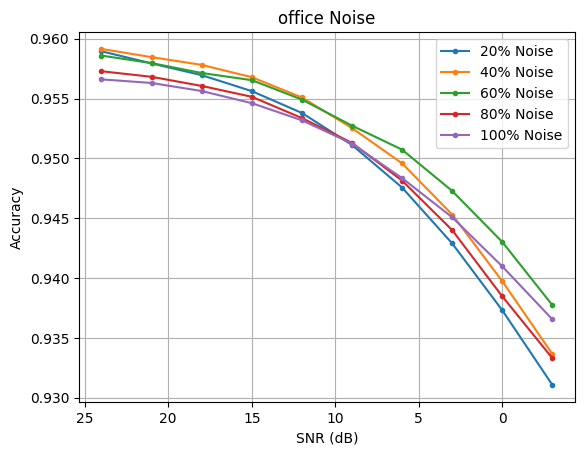

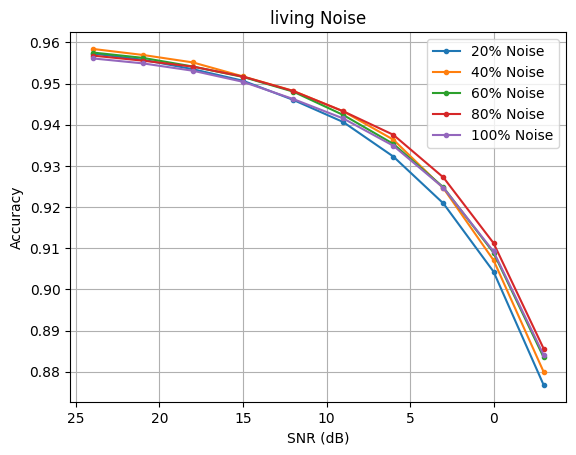

In [ ]:
# Plot the performance for each model trained with noise
df_seed = pd.read_csv('results/full_precision_seed_train_with_noise.csv') 
data = df_seed[df_seed['noise_test'] != 'Noiseless']

# Get unique noise tests
noise_tests = data['noise_test'].unique()

# Plot for each noise test
for noise_test in noise_tests:
    if noise_test == 'Noiseless':
        continue  # Skip Noiseless as it has no SNR values
    
    filtered_data = data[data['noise_test'] == noise_test]
    noise_percentages = filtered_data['noise_percentage'].unique()
    
    plt.figure()
    plt.title(f'{noise_test} Noise')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Accuracy')
    
    for percentage in noise_percentages:
        percentage_subset = filtered_data[filtered_data['noise_percentage'] == percentage]
        avg_data = percentage_subset.groupby('noise_snr')['accuracy'].mean().reset_index()
        plt.plot(avg_data['noise_snr'], avg_data['accuracy'], 
                label=f'{percentage}% Noise', marker=".")
    
    axes = plt.gca()
    axes.invert_xaxis()
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_1852033/288112456.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


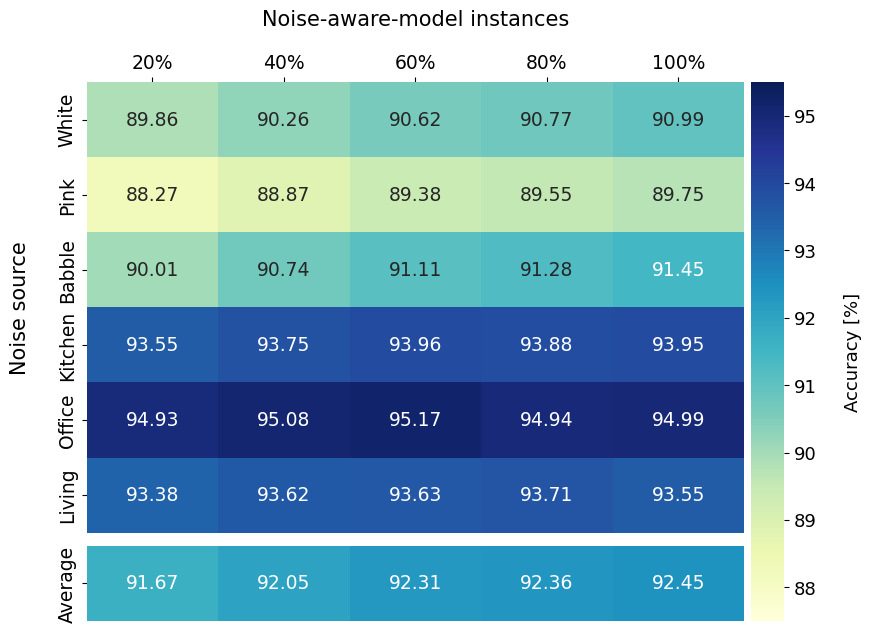

In [ ]:
# Plot the performance computing the averages across the seeds
plt.rc('axes', axisbelow=True)
size = 15

df = pd.read_csv('results/full_precision_seed_train_with_noise.csv')
df = df[(df['noise_test'] != 'Noiseless')]

heatmap_data = df.groupby(['noise_percentage', 'noise_test'])['accuracy'].mean().unstack()
heatmap_data *= 100
column_order = ['white', 'pink', 'babble', 'kitchen', 'office', 'living']
heatmap_data = heatmap_data[column_order]
heatmap_data = heatmap_data.T
averages = heatmap_data.mean(axis=0).to_frame('Average').T

heatmap_data.columns = [f'{int(perc)}%' for perc in heatmap_data.columns]
heatmap_data.index = [label.capitalize() for label in heatmap_data.index]
averages.columns = heatmap_data.columns

fig = plt.figure(figsize=(9, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[6, 1], hspace=0.05, 
                      width_ratios=[1, 0.05], wspace=0.02)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
cbar_ax = fig.add_subplot(gs[:, 1])

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            cbar=False,
            ax=ax1,
            vmin=87.5, 
            vmax=95.5,
            annot_kws={"size": size-1.5})

sns.heatmap(averages, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            ax=ax2,
            vmin=87.5, 
            vmax=95.5,
            annot_kws={"size": size-1.5},
            xticklabels=False,
            cbar_ax=cbar_ax,
            cbar_kws={'label': 'Accuracy [%]'})

ax1.set_ylabel('Noise source', fontsize=size)
ax1.set_xlabel('Noise-aware-model instances', fontsize=size)
ax1.yaxis.labelpad = 20
ax1.xaxis.labelpad = 20
ax1.tick_params(axis='both', labelsize=size-1.5)
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')

ax2.tick_params(axis='y', labelsize=size-1.5, rotation=90)
ax2.tick_params(axis='x', bottom=False) 
ax2.axhline(y=1, color='gray', linewidth=0.5)

cbar_ax.tick_params(labelsize=size-2)
cbar_ax.set_ylabel('Accuracy [%]', fontsize=size-2, rotation=90, labelpad=20)

plt.tight_layout()
plt.show()

if False:
  fig.savefig('./figure/noise_aware_extra_percentage.pdf', dpi=900)

In [ ]:
# Statistical significance results
df = pd.read_csv('results/full_precision_seed_train_with_noise.csv')
df.drop_duplicates(inplace=True)
df = df[(df['noise_test'] != 'Noiseless')]

print("Average accuracy per model:")
print(df.groupby('noise_percentage')['accuracy'].mean().sort_values(ascending=False))

# Data preparation for Friedman test
df['condition'] = df['seed'].astype(str) + '_' + df['noise_test'] + '_' + df['noise_snr'].astype(str)
pivot_df = df.pivot(index='condition', columns='noise_percentage', values='accuracy')
model_data = [pivot_df[model].values for model in pivot_df.columns]

# Test de Friedman
stat, p = friedmanchisquare(*model_data)
print("\nFriedmans' Test results:")
print(f"Statistic: {stat:.3f}, p-value: {p}")

if p < 0.05:
    print("There are significant differences between at least a couple of models (p <0.05) ")
    print("\nPairs comparisons (Wilcoxon Signed-Rank Test with Holm adjustment):")
    
    models = pivot_df.columns
    n_models = len(models)
    p_values = []
    comparisons = []
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            model1 = models[i]
            model2 = models[j]
            stat, p_val = stats.wilcoxon(pivot_df[model1], pivot_df[model2])
            comparisons.append(f"{model1} vs {model2}")
            p_values.append(p_val)
    
    # Holm adjustment for multiple comparisons
    reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
    
    results = pd.DataFrame({
        'Comparison': comparisons,
        'Original p-value': p_values,
        'Adjusted p-value': p_adjusted,
        'Significant': reject
    })
    
    print(results.sort_values('Adjusted p-value'))
    
    # Identify the best average model
    best_model = df.groupby('noise_percentage')['accuracy'].mean().idxmax()
    print(f"\nThe average most accuracy model is: {best_model}")
    
else:
    print("There are no significant differences between models (p ≥ 0.05)")
    best_model = df.groupby('noise_percentage')['accuracy'].mean().idxmax()
    print(f"The average most accuracy model is: {best_model}")

Average accuracy per model:
noise_percentage
100    0.924461
80     0.923552
60     0.923106
40     0.920528
20     0.916663
Name: accuracy, dtype: float64

Friedmans' Test results:
Statistic: 1126.856, p-value: 1.142619726729313e-242
There are significant differences between at least a couple of models (p <0.05) 

Pairs comparisons (Wilcoxon Signed-Rank Test with Holm adjustment):
  Comparison  Original p-value  Adjusted p-value  Significant
1   20 vs 60     3.168980e-174     3.168980e-173         True
2   20 vs 80     1.181481e-138     1.063333e-137         True
3  20 vs 100     7.902899e-134     6.322319e-133         True
0   20 vs 40     2.757997e-116     1.930598e-115         True
4   40 vs 60      1.089498e-64      6.536988e-64         True
6  40 vs 100      1.346203e-59      6.731014e-59         True
5   40 vs 80      1.129720e-45      4.518879e-45         True
9  80 vs 100      3.503587e-14      1.051076e-13         True
8  60 vs 100      4.363329e-12      8.726659e-12         

Conclusion:
- The greater the noise is used for training, the greater the performance.
- The model using 100% extra training data, reached the best performance. Therefore, **I decide to use this model from now on as noise-aware model.**

### baseline-model vs. noise-aware model with **general** noise sources.

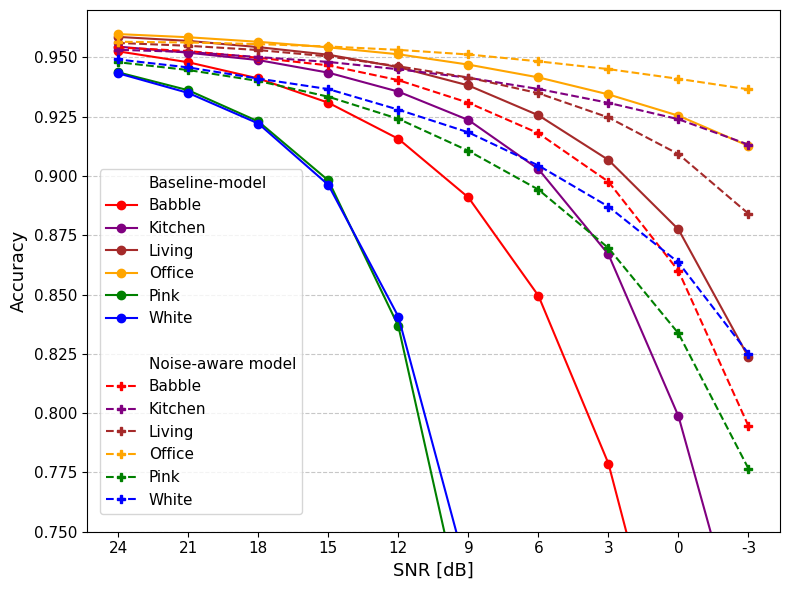

In [ ]:
plt.rc('axes', axisbelow=True)
size = 13

df_original_seeds = pd.read_csv('results/full_precision_seed_train_original.csv')
df_noise_aware_seeds = pd.read_csv('results/full_precision_seed_train_with_noise.csv')

df_baseline = df_original_seeds[df_original_seeds['noise_test'] != 'Noiseless']
df_noise_aware = df_noise_aware_seeds[(df_noise_aware_seeds['noise_test'] != 'Noiseless') & 
                                     (df_noise_aware_seeds['noise_percentage'] == 100)]

def calculate_seed_averages(df):
    return df.groupby(['noise_test', 'noise_snr'])['accuracy'].agg(['mean', 'std']).reset_index()

baseline_avg = calculate_seed_averages(df_baseline)
noise_aware_avg = calculate_seed_averages(df_noise_aware)

noise_test_types = baseline_avg['noise_test'].unique()

color_map = {
    'white': 'blue',
    'pink': 'green',
    'babble': 'red',
    'kitchen': 'purple',
    'office': 'orange',
    'living': 'brown'
}

plt.figure(figsize=(8, 6))

for noise_test in noise_test_types:
    subset = baseline_avg[baseline_avg['noise_test'] == noise_test]
    plt.plot(subset['noise_snr'], subset['mean'], label=f'{noise_test.capitalize()}', 
             marker="o", color=color_map[noise_test])

for noise_test in noise_test_types:
    subset = noise_aware_avg[noise_aware_avg['noise_test'] == noise_test]
    plt.plot(subset['noise_snr'], subset['mean'], label=f'{noise_test.capitalize()}', 
             marker="P", color=color_map[noise_test], linestyle='--')

subtitle1 = mpatches.Patch(color='white', alpha=0)  # Invisible handle
handles, labels = plt.gca().get_legend_handles_labels()
handles.insert(0, subtitle1)
labels.insert(0, 'Baseline-model')
handles.insert(7, subtitle1)
labels.insert(7, '')
handles.insert(8, subtitle1)
labels.insert(8, 'Noise-aware model')

axes = plt.gca()
axes.invert_xaxis()
axes.set_ylim(0.75, 0.97)
axes.grid(axis='y', linestyle='--', alpha=0.7)
axes.grid(True, axis='y')

snr_values = baseline_avg['noise_snr'].dropna().unique()
axes.set_xticks(np.arange(int(min(snr_values)), int(max(snr_values)) + 1, 3))
axes.set_xticklabels(np.arange(int(min(snr_values)), int(max(snr_values)) + 1, 3))

plt.xlabel('SNR [dB]', fontsize=size)
plt.ylabel('Accuracy', fontsize=size)
axes.tick_params(axis='both', labelsize=size-2)

plt.legend(handles, labels, bbox_to_anchor=(0.165, 0.02), loc='lower center', ncol=1,
           fontsize=11)

plt.tight_layout()
fig = plt.gcf()

plt.show()

if False:
    fig.savefig('./figure/baseline_vs_noiseaware_general_noise_seed_avg.pdf', dpi=900)

Conclusions:
- **The noise-aware model performs better than the original model for all noise types.**

# Goal 4: Compare in **specific** noise sources.
From now on, I work with the baseline model and the noise-aware-model trained with 100% noise.
I use the model trained with the standard seeds, i.e., the adaptation is performed only in one model, no across all models trained with different seeds.

In [ ]:
pretrained_specific_noise_df = pd.DataFrame()

baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))

#test the model
for noise_type in param.NOISE_TYPES:
    for snr_test in param.SNR_VALUES:
        
        test_loader = add_noise_on_set(noise_type,snr_test,test_set_waveform,device,
                                        mel_spectrogram,target="test",suffle=False,
                                        batch_size = param.BATCH_SIZE)
            
        accuracy = test_model_accuracy(test_loader,baseline_model,device)[0]
        print(f'Noise: {noise_type} at {snr_test}dB - Accuracy: {accuracy:.4f}')

        temp_df = pd.DataFrame({
                        "model": "baseline", "noise_type": noise_type,
                        "snr_test": snr_test,"accuracy": accuracy},index=[0])
        pretrained_specific_noise_df = pd.concat([pretrained_specific_noise_df ,temp_df], ignore_index=True)



        accuracy = test_model_accuracy(test_loader,noise_aware_model,device)[0]
        print(f'Noise: {noise_type} at {snr_test}dB - Accuracy: {accuracy:.4f}')

        temp_df = pd.DataFrame({
                        "model": "noise_aware", "noise_type": noise_type,
                        "snr_test": snr_test,"accuracy": accuracy},index=[0])
                
        pretrained_specific_noise_df = pd.concat([pretrained_specific_noise_df ,temp_df], ignore_index=True)

pretrained_specific_noise_df.to_csv("./results/full_precision_pretrain_specific_noise.csv",index=False)
del baseline_model, noise_aware_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

Noise: car_horn_background at -3dB - Accuracy: 0.4301
Noise: car_horn_background at -3dB - Accuracy: 0.3368
Noise: car_horn_background at 0dB - Accuracy: 0.5425
Noise: car_horn_background at 0dB - Accuracy: 0.4288
Noise: car_horn_background at 3dB - Accuracy: 0.6648
Noise: car_horn_background at 3dB - Accuracy: 0.5247
Noise: car_horn_background at 6dB - Accuracy: 0.7585
Noise: car_horn_background at 6dB - Accuracy: 0.6153
Noise: car_horn_background at 9dB - Accuracy: 0.8290
Noise: car_horn_background at 9dB - Accuracy: 0.7037
Noise: car_horn_background at 12dB - Accuracy: 0.8701
Noise: car_horn_background at 12dB - Accuracy: 0.7771
Noise: car_horn_background at 15dB - Accuracy: 0.9014
Noise: car_horn_background at 15dB - Accuracy: 0.8262
Noise: car_horn_background at 18dB - Accuracy: 0.9170
Noise: car_horn_background at 18dB - Accuracy: 0.8691
Noise: car_horn_background at 21dB - Accuracy: 0.9352
Noise: car_horn_background at 21dB - Accuracy: 0.8980
Noise: car_horn_background at 24dB -

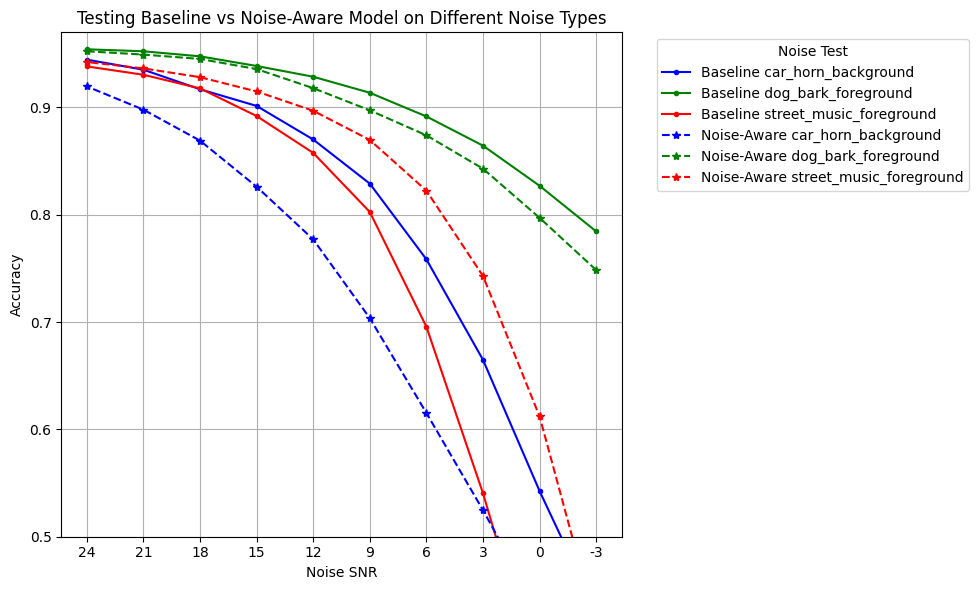

In [14]:
# Filter the noise-aware data for 100% noise
df_noise_aware = pretrained_specific_noise_df[(pretrained_specific_noise_df['model'] == 'noise_aware')]
df_baseline = pretrained_specific_noise_df[(pretrained_specific_noise_df['model'] == 'baseline')]

# Get unique noise_type types
noise_type_types = df_baseline['noise_type'].unique()

# Define a color map for each noise_type type
color_map = {
    'car_horn_background': 'blue',
    'dog_bark_foreground': 'green',
    'street_music_foreground': 'red',
}

# Plotting
plt.figure(figsize=(10, 6))

# Plot Baseline model results
for noise_type in noise_type_types:
    subset = df_baseline[df_baseline['noise_type'] == noise_type]
    plt.plot(subset['snr_test'], subset['accuracy'], label=f'Baseline {noise_type}', 
             marker=".", color=color_map[noise_type])

# Plot noise-aware model results
for noise_type in noise_type_types:
    subset = df_noise_aware[df_noise_aware['noise_type'] == noise_type]
    plt.plot(subset['snr_test'], subset['accuracy'], label=f'Noise-Aware {noise_type}', 
             marker="*", color=color_map[noise_type], linestyle='--')

# Set plot properties
axes = plt.gca()
axes.invert_xaxis()
axes.set_ylim(0.5, 0.97)

# Set x-axis ticks with a step of 3
snr_values = df_baseline['snr_test'].dropna().unique()
axes.set_xticks(range(int(min(snr_values)), int(max(snr_values)) + 1, 3))
axes.set_xticklabels(range(int(min(snr_values)), int(max(snr_values)) + 1, 3))

plt.xlabel('Noise SNR')
plt.ylabel('Accuracy')
plt.title('Testing Baseline vs Noise-Aware Model on Different Noise Types')
plt.legend(title='Noise Test', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Conclusions:
- When testing on specific noise types, the baseline model performs better than the noise-aware model. That is not what someone expected.
- The noise-aware model may loose generalization capabilities compared with the baseline model.

# Goal 5: Active learning models

Evaluation of the required number of epochs for reaching good accuracy using few-shot learning (1 to 5 shots).

As the number of epochs increase, it is expected that the model overfit due to the low number of training data.

***Since it is expected that the model update the parameters (learning) in real-time, the noise audio file it is the same for training and testing.***

In this case, I use the test_set as the validation_set 

## 1-shot / 5 epochs

In [ ]:
sub_train_set_waveform_1samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=1)

epochs = 5
batch_lenght=len(sub_train_set_waveform_1samples_per_class)

few_shot_1_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:

        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_1samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models
        print("--------------------------------\n")
        print("Train Baseline model: " + noise_type + " at " +str(snr_train)+ "dB")
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_1_df = pd.concat([few_shot_1_df ,temp_df], ignore_index=True)
        

        print("Train Noise-aware model: " + noise_type + " at " +str(snr_train)+ "dB")
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "noise_aware", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_1_df = pd.concat([few_shot_1_df ,temp_df], ignore_index=True)


few_shot_1_df.to_csv("./results/few_shot_1.csv",index=False)

del train_loader,test_loader,noise_aware_model,baseline_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

--------------------------------

Train Baseline model: car_horn_background at -3dB
Train Noise-aware model: car_horn_background at -3dB
--------------------------------

Train Baseline model: car_horn_background at 0dB
Train Noise-aware model: car_horn_background at 0dB
--------------------------------

Train Baseline model: car_horn_background at 3dB
Train Noise-aware model: car_horn_background at 3dB
--------------------------------

Train Baseline model: car_horn_background at 6dB
Train Noise-aware model: car_horn_background at 6dB
--------------------------------

Train Baseline model: car_horn_background at 9dB
Train Noise-aware model: car_horn_background at 9dB
--------------------------------

Train Baseline model: car_horn_background at 12dB
Train Noise-aware model: car_horn_background at 12dB
--------------------------------

Train Baseline model: car_horn_background at 15dB
Train Noise-aware model: car_horn_background at 15dB
--------------------------------

Train Baseline 

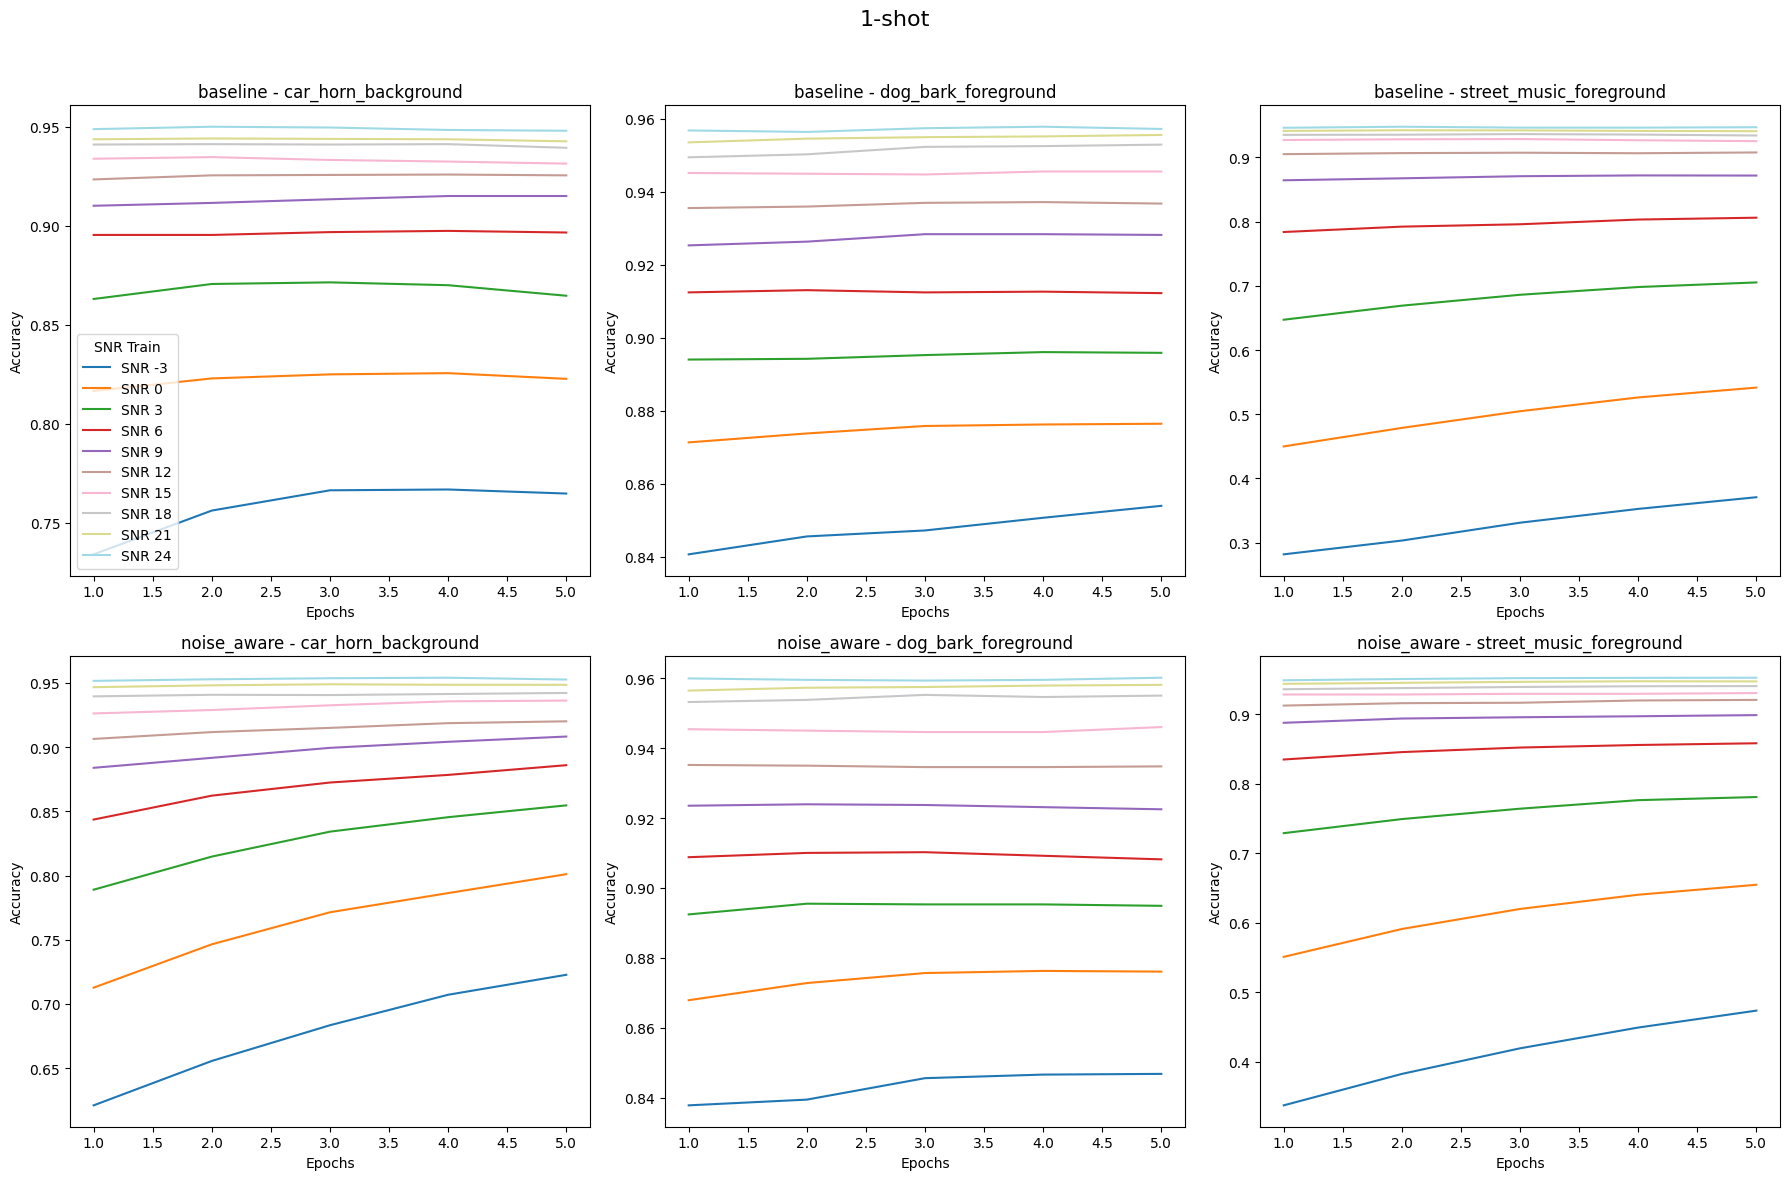

In [ ]:
plot_epochs_evolution(data=pd.read_csv('./results/few_shot_1.csv'),title='1-shot')

## 2-shots / 5 epochs

In [ ]:
sub_train_set_waveform_2samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=2)

epochs = 5
batch_lenght=len(sub_train_set_waveform_2samples_per_class)

few_shot_2_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:

        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_2samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate = param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_2_df = pd.concat([few_shot_2_df ,temp_df], ignore_index=True)
        

        _, epochs_accuracy = continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate = param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "noise_aware", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_2_df = pd.concat([few_shot_2_df ,temp_df], ignore_index=True)


few_shot_2_df.to_csv("./results/few_shot_2.csv",index=False)

del train_loader,test_loader,noise_aware_model,baseline_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

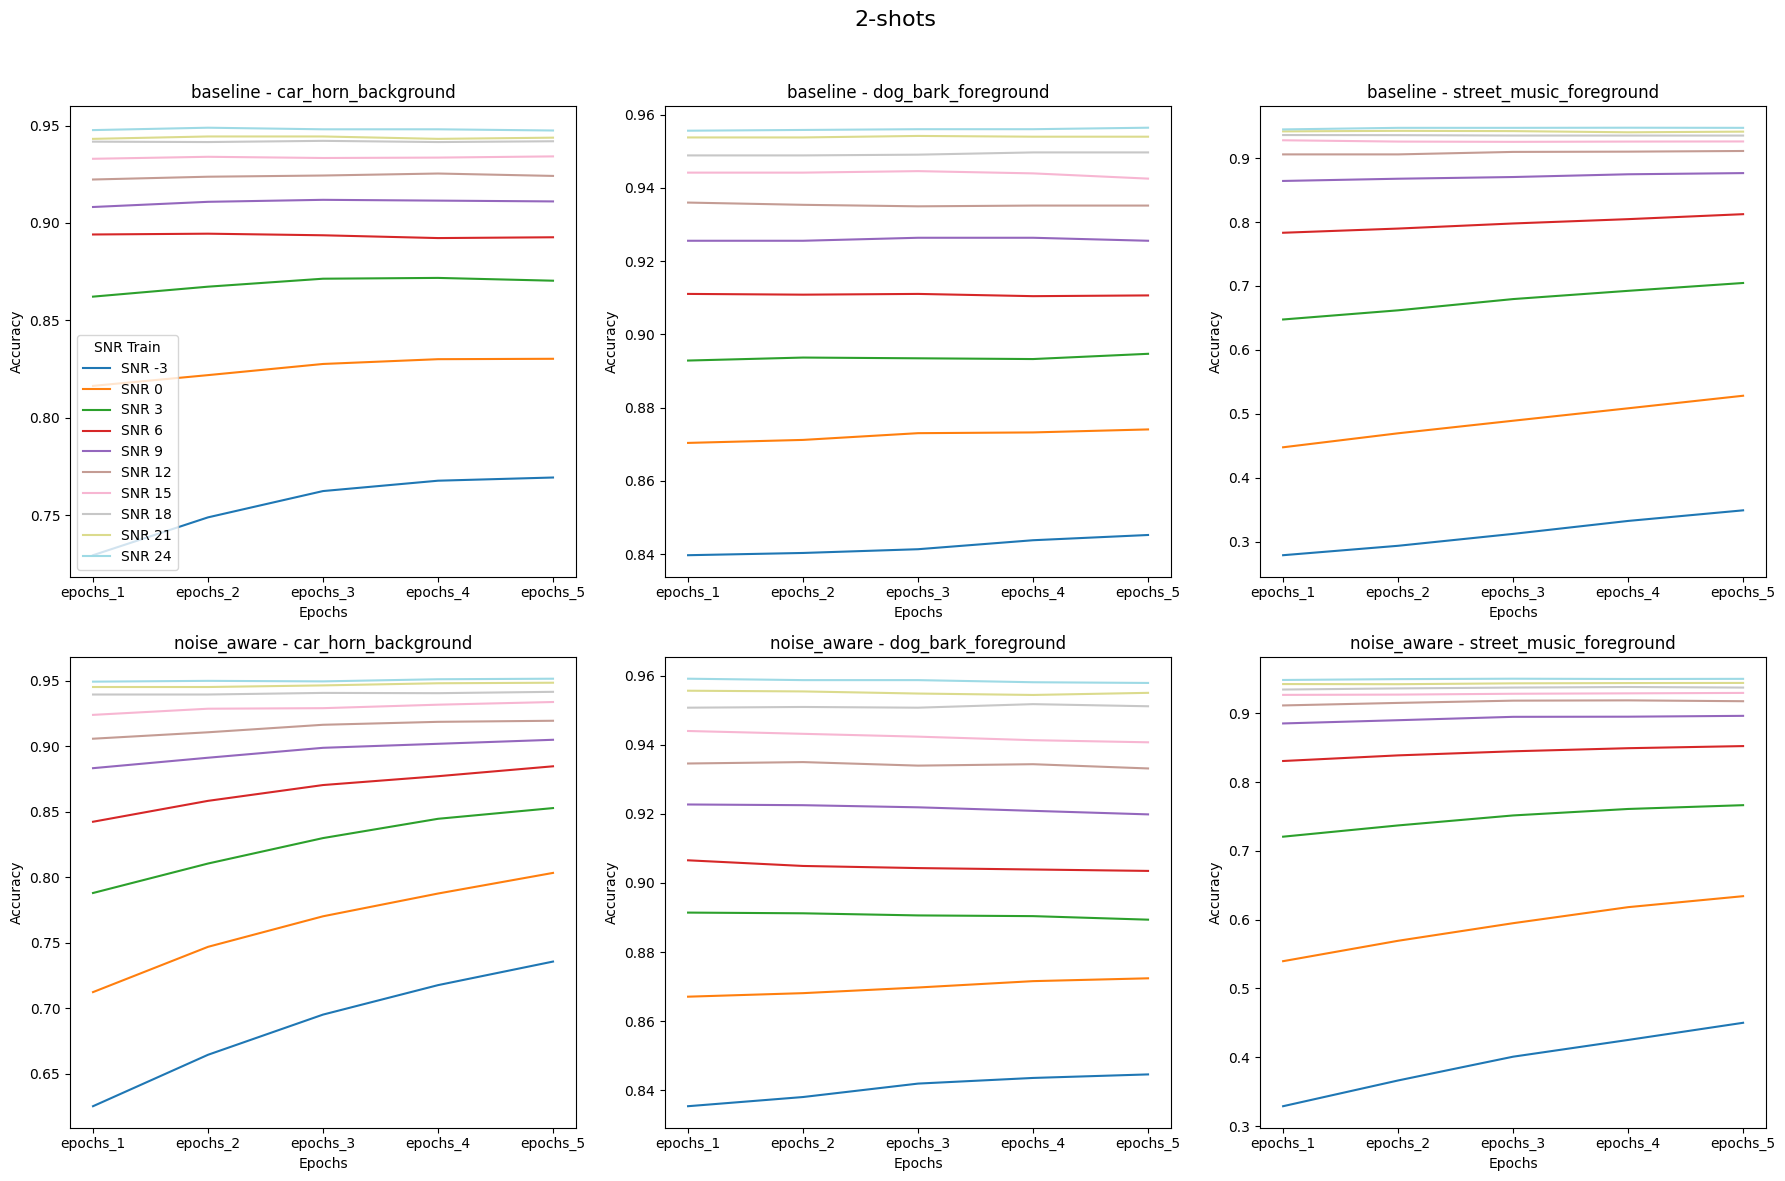

In [ ]:
plot_epochs_evolution(data=pd.read_csv('./results/few_shot_2.csv'),title='2-shots')

## 3-shot / 5 epochs

In [ ]:
sub_train_set_waveform_3samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=3)

epochs = 5
batch_lenght=len(sub_train_set_waveform_3samples_per_class)

few_shot_3_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:
        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_3samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_3_df = pd.concat([few_shot_3_df ,temp_df], ignore_index=True)
        

        _, epochs_accuracy = continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "noise_aware", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_3_df = pd.concat([few_shot_3_df ,temp_df], ignore_index=True)


few_shot_3_df.to_csv("./results/few_shot_3.csv",index=False)

del train_loader,test_loader,noise_aware_model,baseline_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

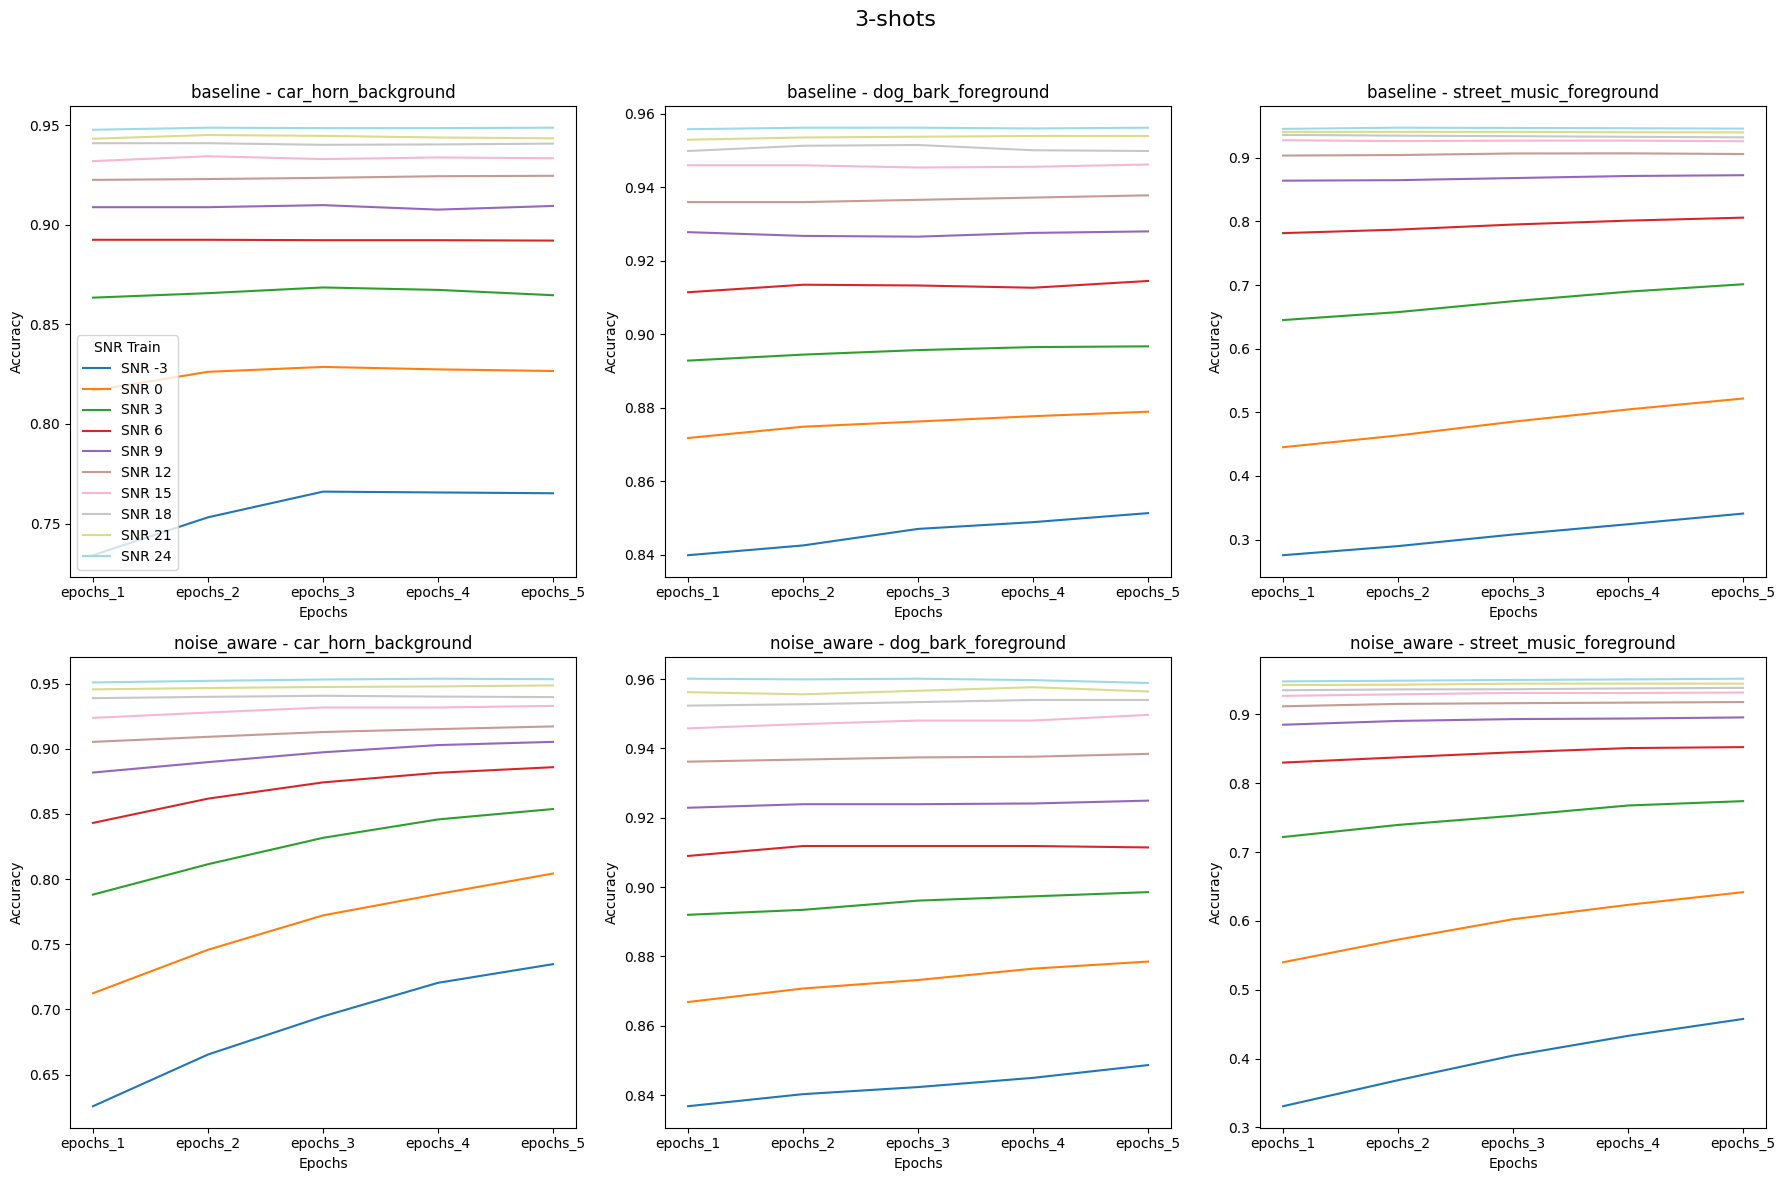

In [ ]:
plot_epochs_evolution(data=pd.read_csv('./results/few_shot_3.csv'),title='3-shots')

## 4-shots / 5 epochs

In [ ]:
sub_train_set_waveform_4samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=4)

epochs = 5
batch_lenght=len(sub_train_set_waveform_4samples_per_class)
few_shot_4_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:
        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_4samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate =param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_4_df = pd.concat([few_shot_4_df ,temp_df], ignore_index=True)
        

        _, epochs_accuracy = continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate = param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "noise_aware", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_4_df = pd.concat([few_shot_4_df ,temp_df], ignore_index=True)


few_shot_4_df.to_csv("./results/few_shot_4.csv",index=False)

del train_loader,test_loader,noise_aware_model,baseline_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

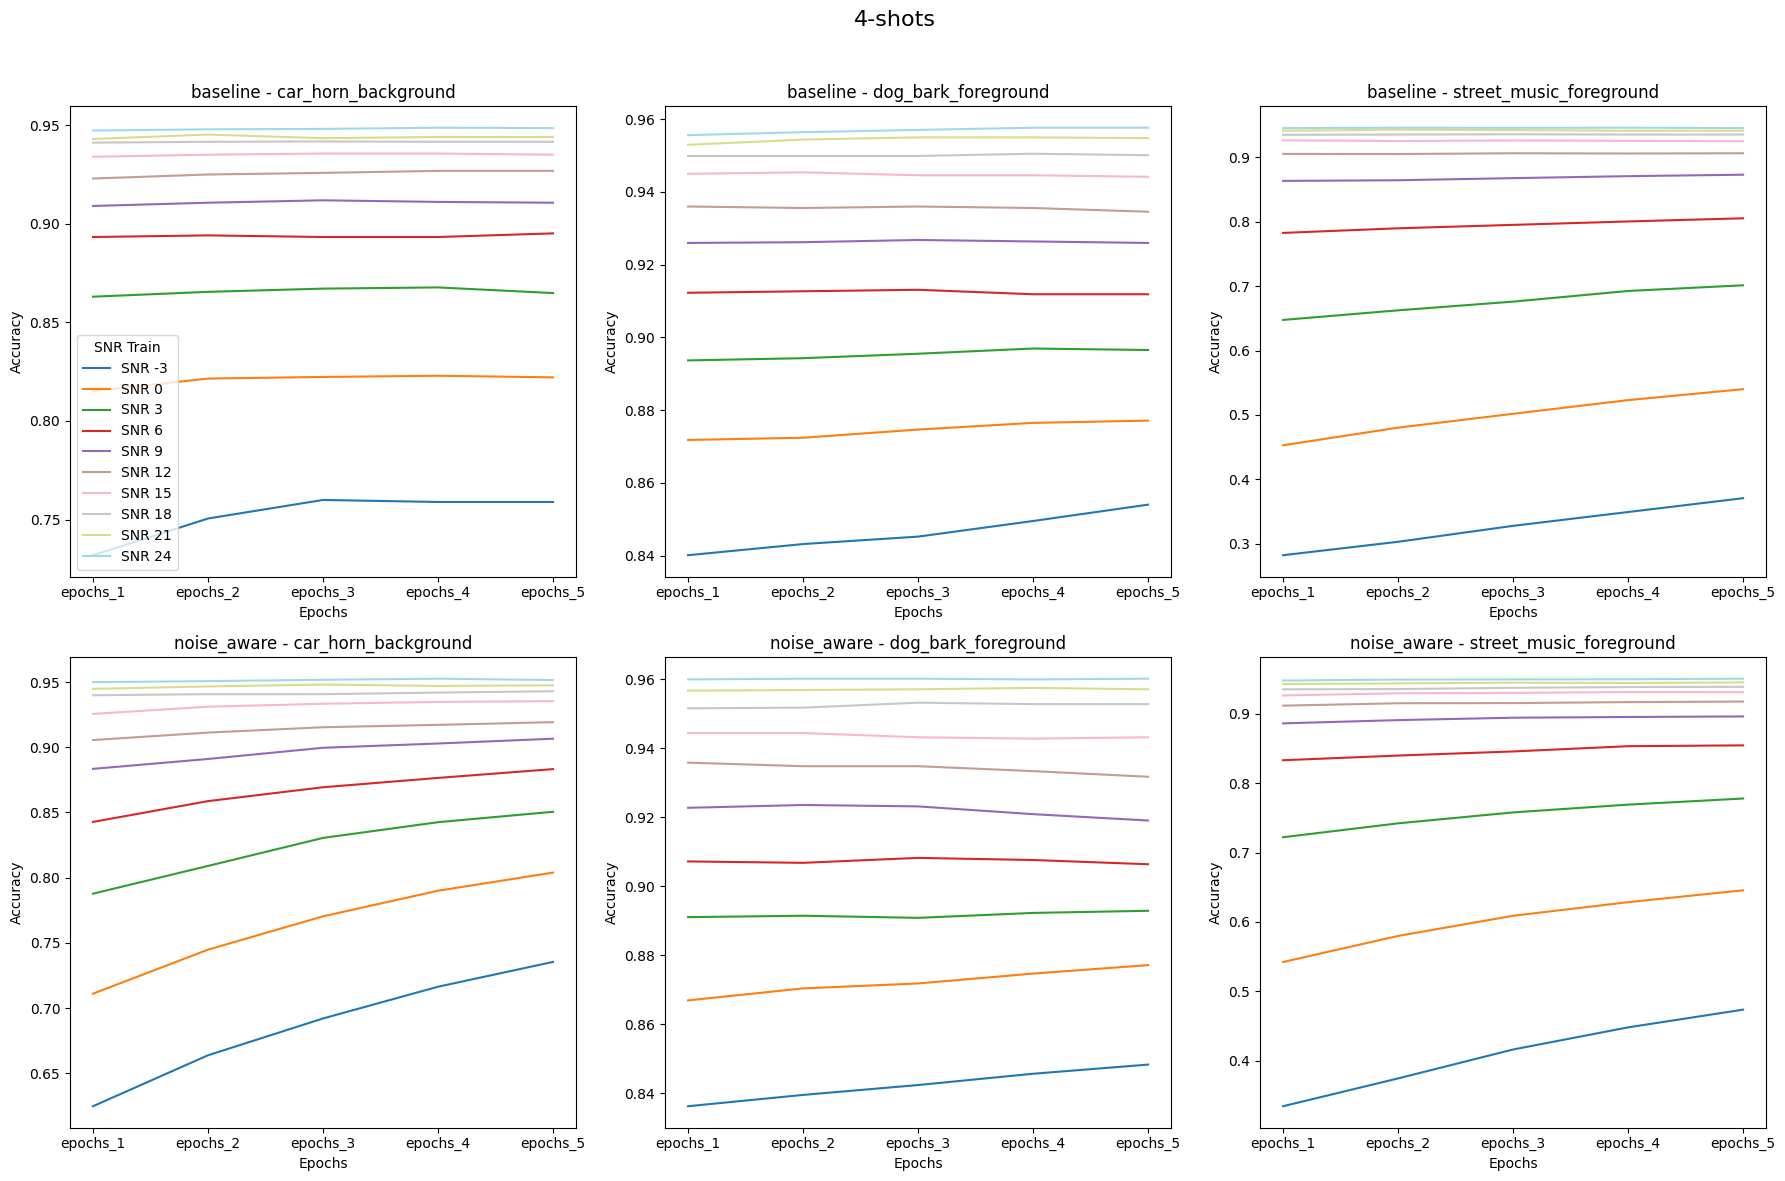

In [ ]:
plot_epochs_evolution(data=pd.read_csv('./results/few_shot_4.csv'),title='4-shots')

## 5-shots / 5 epochs

In [ ]:
sub_train_set_waveform_5samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=5)

epochs = 5
batch_lenght=len(sub_train_set_waveform_5samples_per_class)
few_shot_5_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:
        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_5samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models
        _, epochs_accuracy = continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate =param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_5_df = pd.concat([few_shot_5_df ,temp_df], ignore_index=True)
        

        _, epochs_accuracy = continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate =param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        
        temp_df = pd.DataFrame({
            "model": "noise_aware", "noise_type": noise_type, "snr_train": snr_train},index=[0])
        
        for i in range(len(epochs_accuracy)):
             temp_df[f'epochs_{i+1}'] = epochs_accuracy[i]

        few_shot_5_df = pd.concat([few_shot_5_df ,temp_df], ignore_index=True)


few_shot_5_df.to_csv("./results/few_shot_5.csv",index=False)

del train_loader,test_loader,noise_aware_model,baseline_model
torch.cuda.synchronize()
torch.cuda.empty_cache()

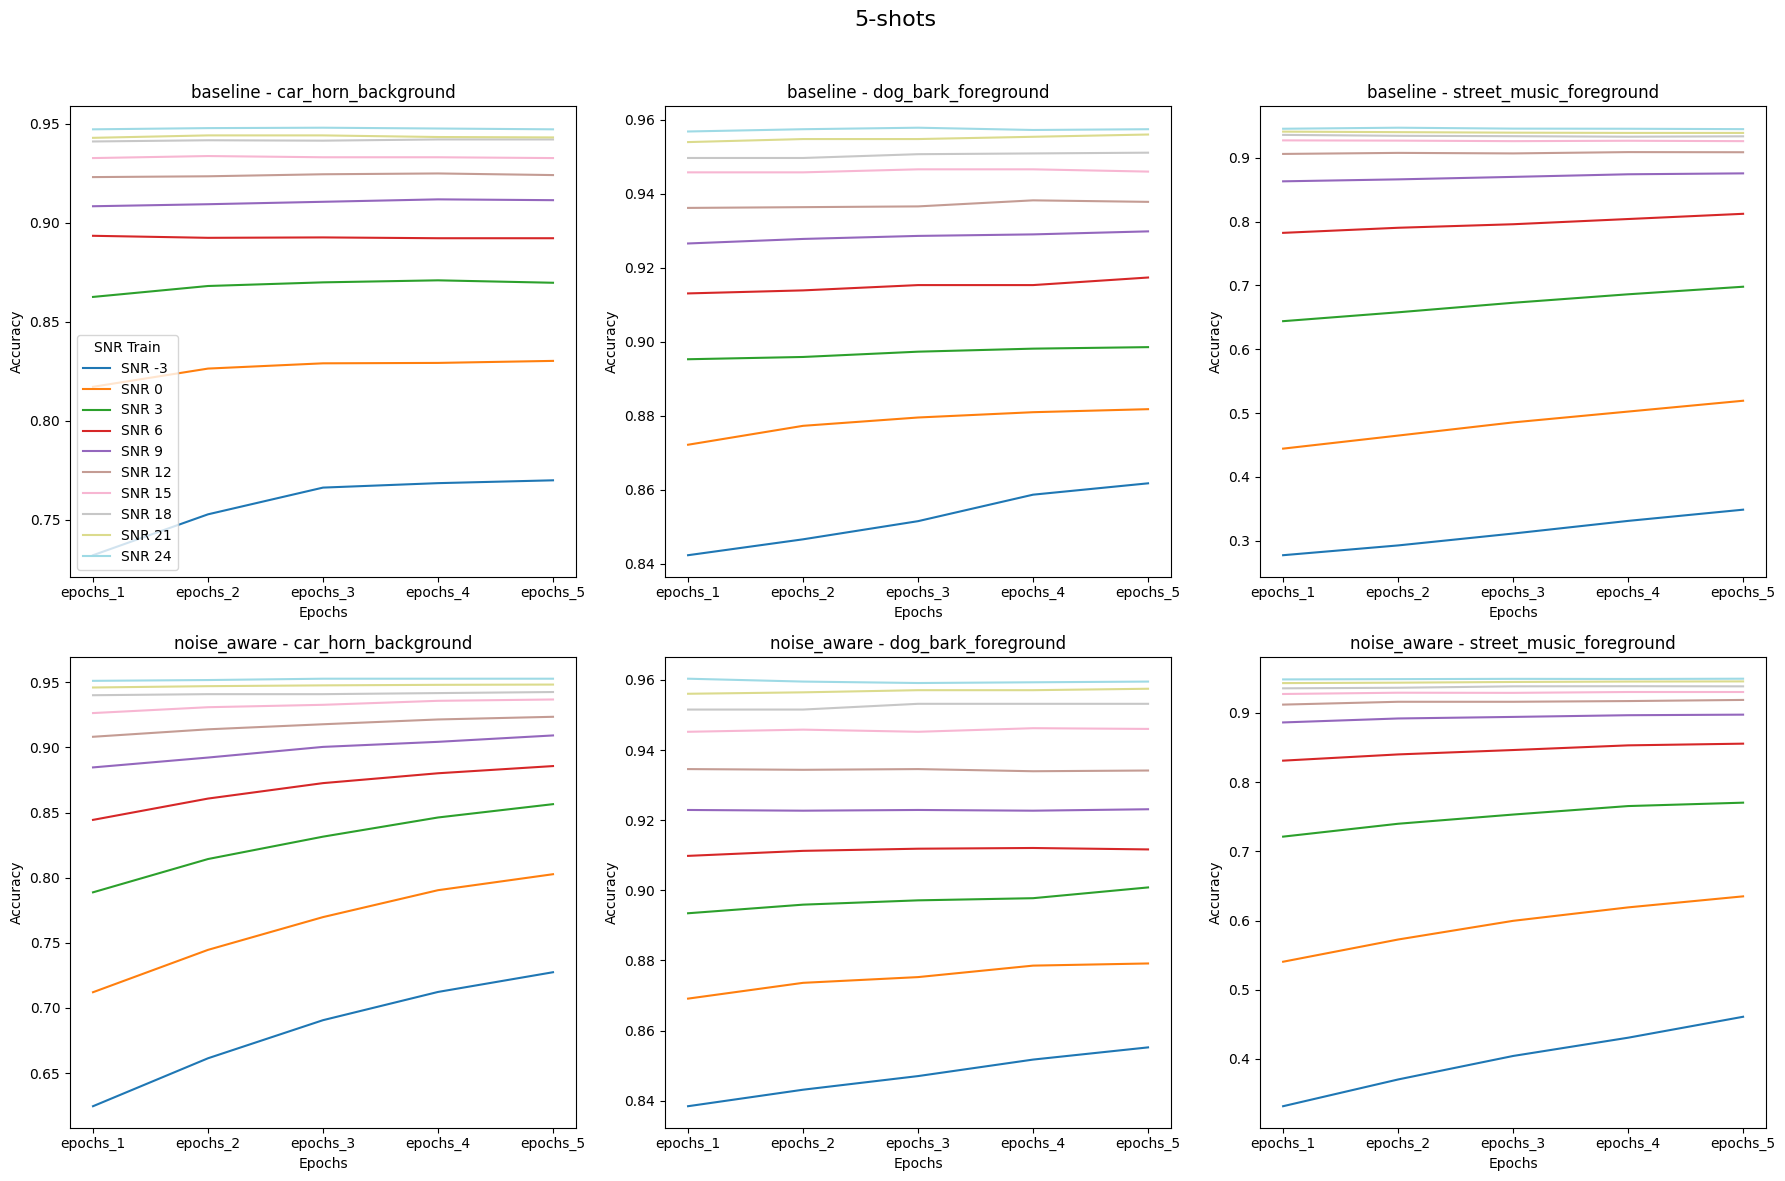

In [ ]:
plot_epochs_evolution(data=pd.read_csv('./results/few_shot_5.csv'),title='5-shots')

## 1 to 5 shots / 1 epoch

In [ ]:
epochs = 1

for i in range(1,6):
    sub_train_set_waveform_i_samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=i)


    batch_lenght=len(sub_train_set_waveform_i_samples_per_class)


    few_shot_epochs_1_df = pd.DataFrame()

    for noise_type in param.NOISE_TYPES:
        for snr_train in param.SNR_VALUES:

            
            train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_i_samples_per_class,device,
                                    mel_spectrogram,target="train",suffle=True,
                                    batch_size=batch_lenght)
            
            test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                    mel_spectrogram,target="train",suffle=False,
                                    batch_size=batch_lenght)
            
            # reload the models
            baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
            baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
            noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
            noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
            
            # active-learning models
            continue_training_model(train_loader, test_loader, baseline_model,device,
                                learning_rate =param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
            continue_training_model(train_loader, test_loader, noise_aware_model,device,
                                learning_rate =param.LEARNING_RATE,num_epochs=epochs,show_plot=False)

            #test the model
            for snr_test in param.SNR_VALUES:
                
                test_loader = add_noise_on_set(noise_type,snr_test,test_set_waveform,device,
                                    mel_spectrogram,target="train",suffle=False,
                                    batch_size=batch_lenght)
                
                print("Test Baseline model: " + noise_type + " at " +str(snr_test)+ "dB")
                accuracy = test_model_accuracy(test_loader,baseline_model,device)[0]
                temp_df = pd.DataFrame({
                                "model": "baseline", "noise_type": noise_type, "snr_train": snr_train,
                                "snr_test": snr_test, "accuracy": accuracy},index=[0])
                        
                few_shot_epochs_1_df = pd.concat([few_shot_epochs_1_df ,temp_df], ignore_index=True)

                print("Test Noise-aware model: " + noise_type + " at " +str(snr_test)+ "dB")
                accuracy = test_model_accuracy(test_loader,noise_aware_model,device)[0]

                temp_df = pd.DataFrame({
                                "model": "noise-aware", "noise_type": noise_type, "snr_train": snr_train,
                                "snr_test": snr_test, "accuracy": accuracy},index=[0])
                        
                few_shot_epochs_1_df = pd.concat([few_shot_epochs_1_df ,temp_df], ignore_index=True)

    few_shot_epochs_1_df.to_csv("./results/few_shot_"+str(i)+"_epochs_1.csv",index=False)

Test Baseline model: car_horn_background at -3dB
Test Noise-aware model: car_horn_background at -3dB
Test Baseline model: car_horn_background at 0dB
Test Noise-aware model: car_horn_background at 0dB
Test Baseline model: car_horn_background at 3dB
Test Noise-aware model: car_horn_background at 3dB
Test Baseline model: car_horn_background at 6dB
Test Noise-aware model: car_horn_background at 6dB
Test Baseline model: car_horn_background at 9dB
Test Noise-aware model: car_horn_background at 9dB
Test Baseline model: car_horn_background at 12dB
Test Noise-aware model: car_horn_background at 12dB
Test Baseline model: car_horn_background at 15dB
Test Noise-aware model: car_horn_background at 15dB
Test Baseline model: car_horn_background at 18dB
Test Noise-aware model: car_horn_background at 18dB
Test Baseline model: car_horn_background at 21dB
Test Noise-aware model: car_horn_background at 21dB
Test Baseline model: car_horn_background at 24dB
Test Noise-aware model: car_horn_background at 24d

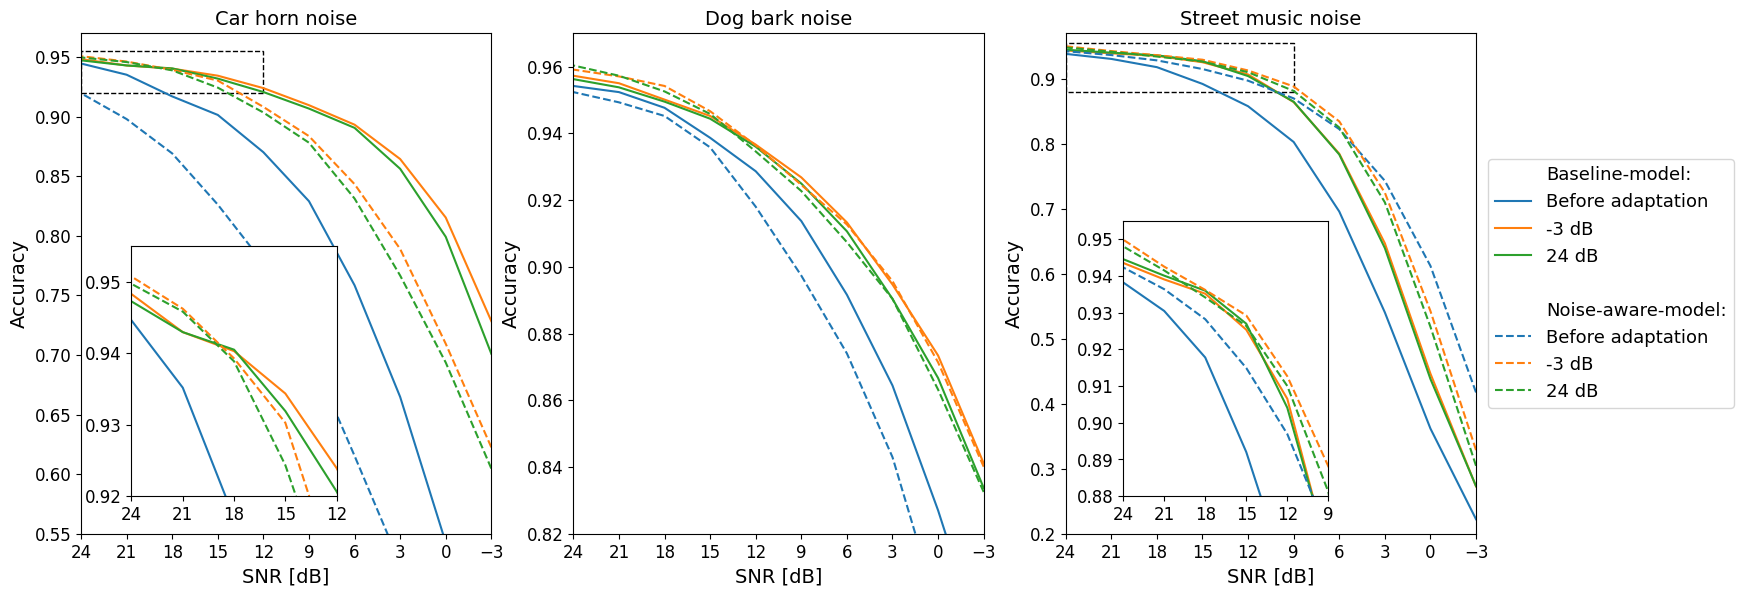

In [ ]:
df_few_shot = pd.read_csv("./results/few_shot_1_epochs_1.csv")
df_baseline = pd.read_csv("./results/full_precision_pretrain_specific_noise.csv")
    
size = 14
df_few_shot = df_few_shot[df_few_shot['snr_train'].isin([-3, 24])]

noise_types = df_baseline['noise_type'].unique()

df_baseline_baseline = df_baseline[df_baseline['model'] == 'baseline']
df_few_shot_baseline = df_few_shot[df_few_shot['model'] == 'baseline']

df_baseline_noise_aware = df_baseline[df_baseline['model'] == 'noise_aware']
df_few_shot_noise_aware = df_few_shot[df_few_shot['model'] == 'noise-aware']

fig, axes = plt.subplots(1, len(noise_types), figsize=(18, 6.5))
axes = axes.flatten()
colors = mpl.colormaps['tab10'].colors

for i, noise_type in enumerate(noise_types):
    ax = axes[i]
    
    baseline_data = df_baseline_baseline[df_baseline_baseline['noise_type'] == noise_type]
    ax.plot(baseline_data['snr_test'], baseline_data['accuracy'], color=colors[0], linestyle='-', 
            label='Before adaptation')
    

    few_shot_data = df_few_shot_baseline[df_few_shot_baseline['noise_type'] == noise_type]
    snr_train_values = few_shot_data['snr_train'].unique()
    for j, snr_train in enumerate(snr_train_values):
        subset = few_shot_data[few_shot_data['snr_train'] == snr_train]
        ax.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='-', label=f'{snr_train} dB')
    
    baseline_data_noise_aware = df_baseline_noise_aware[df_baseline_noise_aware['noise_type'] == noise_type]
    ax.plot(baseline_data_noise_aware['snr_test'], baseline_data_noise_aware['accuracy'], color=colors[0], linestyle='--', 
            label='Before adaptation')
    
    
    few_shot_data_noise_aware = df_few_shot_noise_aware[df_few_shot_noise_aware['noise_type'] == noise_type]
    snr_train_values = few_shot_data_noise_aware['snr_train'].unique()
    for j, snr_train in enumerate(snr_train_values):
        subset = few_shot_data_noise_aware[few_shot_data_noise_aware['snr_train'] == snr_train]
        ax.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='--', label=f'{snr_train} dB')
    
    ax.set_xlabel('SNR [dB]', fontsize=size)
    ax.set_ylabel('Accuracy', fontsize=size)
    ax.set_xticks(np.arange(-3, 25, 3))
    ax.set_xlim(-3,24)
    ax.invert_xaxis()
    ax.tick_params(axis='both', labelsize=size-2)

ymax= 0.97
axes[0].set_ylim([0.55, ymax])
axes[1].set_ylim([0.82, ymax])
axes[2].set_ylim([0.2, ymax])
axes[0].set_title("Car horn noise",fontsize=size)
axes[1].set_title("Dog bark noise",fontsize=size)
axes[2].set_title("Street music noise",fontsize=size)


handles, labels = ax.get_legend_handles_labels()  
subtitle1 = mpatches.Patch(color='white', alpha=0)

handles.insert(0, subtitle1)
labels.insert(0, 'Baseline-model:')
handles.insert(4, subtitle1)
labels.insert(4, '')
handles.insert(5, subtitle1)
labels.insert(5, 'Noise-aware-model:')


plt.legend(handles, labels, title='', 
           bbox_to_anchor=(1.65, 0.5), ncol=1, loc='center right', 
           fontsize=size-1)


# ZOOM-IN THE FIRST SUBPLOT
axins = axes[0].inset_axes([0.123, 0.075, 0.5, 0.5])

baseline_data = df_baseline_baseline[df_baseline_baseline['noise_type'] == noise_types[0]]
axins.plot(baseline_data['snr_test'], baseline_data['accuracy'], color=colors[0], linestyle='-')

few_shot_data = df_few_shot_baseline[df_few_shot_baseline['noise_type'] == noise_types[0]]
snr_train_values = few_shot_data['snr_train'].unique()
for j, snr_train in enumerate(snr_train_values):
    subset = few_shot_data[few_shot_data['snr_train'] == snr_train]
    axins.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='-')

baseline_data_noise_aware = df_baseline_noise_aware[df_baseline_noise_aware['noise_type'] == noise_types[0]]
axins.plot(baseline_data_noise_aware['snr_test'], baseline_data_noise_aware['accuracy'], color=colors[0], linestyle='--')


few_shot_data_noise_aware = df_few_shot_noise_aware[df_few_shot_noise_aware['noise_type'] == noise_types[0]]
snr_train_values = few_shot_data_noise_aware['snr_train'].unique()
for j, snr_train in enumerate(snr_train_values):
    subset = few_shot_data_noise_aware[few_shot_data_noise_aware['snr_train'] == snr_train]
    axins.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='--')


x1, x2, y1, y2 = 24, 12, 0.92, 0.955
axins.set_xlim(x2 ,x1)
axins.set_ylim(y1, y2)
axins.set_xticks(np.arange(24, 11, -3))
axins.set_yticks(np.arange(y1, y2, 0.01))
axins.tick_params(axis='both', labelsize=size-2)

axins.invert_xaxis()
rect = Rectangle((x2, y1), x1 - x2, y2 - y1, linestyle='dashed', edgecolor='black', facecolor='none')
axes[0].add_patch(rect)


# ZOOM-IN THE THIRD SUBPLOT
axins = axes[2].inset_axes([0.14, 0.075, 0.5, 0.55])
baseline_data = df_baseline_baseline[df_baseline_baseline['noise_type'] == noise_types[2]]
axins.plot(baseline_data['snr_test'], baseline_data['accuracy'], color=colors[0], linestyle='-')

few_shot_data = df_few_shot_baseline[df_few_shot_baseline['noise_type'] == noise_types[2]]
snr_train_values = few_shot_data['snr_train'].unique()
for j, snr_train in enumerate(snr_train_values):
    subset = few_shot_data[few_shot_data['snr_train'] == snr_train]
    axins.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='-')

baseline_data_noise_aware = df_baseline_noise_aware[df_baseline_noise_aware['noise_type'] == noise_types[2]]
axins.plot(baseline_data_noise_aware['snr_test'], baseline_data_noise_aware['accuracy'], color=colors[0], linestyle='--')


few_shot_data_noise_aware = df_few_shot_noise_aware[df_few_shot_noise_aware['noise_type'] == noise_types[2]]
snr_train_values = few_shot_data_noise_aware['snr_train'].unique()
for j, snr_train in enumerate(snr_train_values):
    subset = few_shot_data_noise_aware[few_shot_data_noise_aware['snr_train'] == snr_train]
    axins.plot(subset['snr_test'], subset['accuracy'], color=colors[j + 1], linestyle='--')


x1, x2, y1, y2 = 24, 9, 0.88, 0.955
axins.set_xlim(x2 ,x1)
axins.set_ylim(y1, y2)
axins.set_xticks(np.arange(24, x2-1, -3))
axins.tick_params(axis='both', labelsize=size-2)
axins.invert_xaxis()

rect = Rectangle((x2, y1), x1 - x2, y2 - y1, linestyle='dashed', edgecolor='black', facecolor='none')
axes[2].add_patch(rect)

fig = plt.gcf()

plt.show()

if False:
    fig.savefig('./figure/1_shot_1_epoch.pdf', dpi=900,bbox_inches='tight')

# plots for the paper

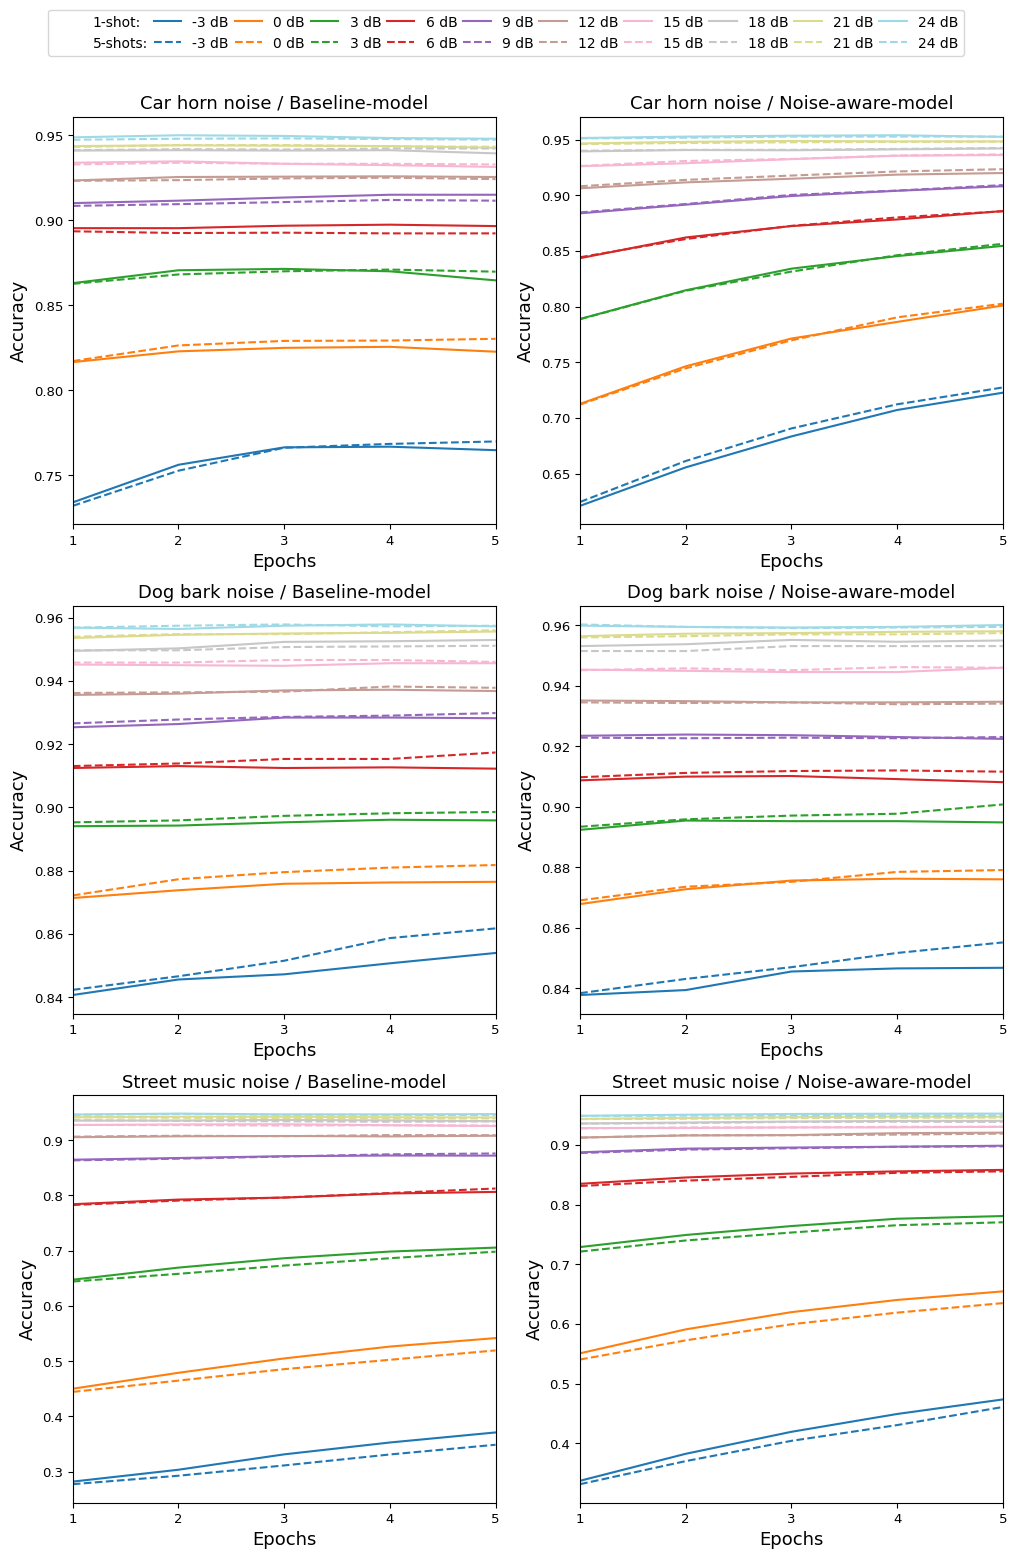

In [ ]:
def plot_epochs_evolution(data1, data2, title):
    size = 13
    #  Add a column to identify the dataset
    data1_copy = data1.copy()
    data1_copy['dataset'] = 'data1'
    data2_copy = data2.copy()
    data2_copy['dataset'] = 'data2'
    combined_data = pd.concat([data1_copy, data2_copy], ignore_index=True)

    models = ['baseline', 'noise_aware']
    noise_types = combined_data['noise_type'].unique()

    fig, axes = plt.subplots(3,2, figsize=(12, 18))
    fig.suptitle(title, fontsize=16)

    colors = plt.cm.tab20(np.linspace(0, 1, len(combined_data['snr_train'].unique())))

    for i, noise_type in enumerate(noise_types):
        for j, model in enumerate(models):
        
            ax = axes[i, j]
            
            subset1 = data1[(data1['model'] == model) & (data1['noise_type'] == noise_type)]
            subset2 = data2[(data2['model'] == model) & (data2['noise_type'] == noise_type)]
            
            for idx, snr in enumerate(subset1['snr_train'].unique()):
                snr_subset1 = subset1[subset1['snr_train'] == snr]
                epochs = [f'epochs_{k+1}' for k in range(5)]
                ax.plot([1,2,3,4,5], snr_subset1[epochs].values.flatten(), label=f'{snr} dB', color=colors[idx], linestyle='-')
            
            for idx, snr in enumerate(subset2['snr_train'].unique()):
                snr_subset2 = subset2[subset2['snr_train'] == snr]
                epochs = [f'epochs_{k+1}' for k in range(5)]
                ax.plot([1,2,3,4,5], snr_subset2[epochs].values.flatten(), label=f'{snr} dB', color=colors[idx], linestyle='--')
            
            ax.set_title(f'{model} - {noise_type}')
            ax.set_xlabel('Epochs',fontsize=size)
            ax.set_ylabel('Accuracy',fontsize=size)
            ax.set_xticks([1, 2, 3, 4, 5])
            ax.set_xlim(1,5)
            ax.tick_params(axis='both', labelsize=size-3.5)

        
    handles, labels = plt.gca().get_legend_handles_labels()
    subtitle1 = mpatches.Patch(color='white', alpha=0)

    handles.insert(0, subtitle1)
    labels.insert(0, '1-shot:')
    handles.insert(11, subtitle1)
    labels.insert(11, '5-shots:')

    reordered_handles = [handles[0], handles[0+11], 
                        handles[1], handles[1+11], 
                        handles[2], handles[2+11],
                        handles[3], handles[3+11], 
                        handles[4], handles[4+11], 
                        handles[5], handles[5+11],
                        handles[6], handles[6+11], 
                        handles[7], handles[7+11], 
                        handles[8], handles[8+11], 
                        handles[9], handles[9+11],
                        handles[10], handles[10+11]]
    reordered_labels = [labels[0], labels[0+11],
                        labels[1], labels[1+11], 
                        labels[2], labels[2+11],
                        labels[3], labels[3+11], 
                        labels[4], labels[4+11], 
                        labels[5], labels[5+11],
                        labels[6], labels[6+11], 
                        labels[7], labels[7+11], 
                        labels[8], labels[8+11], 
                        labels[9], labels[9+11],
                        labels[10], labels[10+11]]

    plt.legend(reordered_handles, reordered_labels,  
               loc='upper center',
               bbox_to_anchor=(-0.175, 3.68), 
               ncol=len(combined_data['snr_train'].unique())+1,
               columnspacing=0.4,
               fontsize=size-3)


    axes[0,0].set_title("Car horn noise / Baseline-model",fontsize=size)
    axes[0,1].set_title("Car horn noise / Noise-aware-model",fontsize=size)
    axes[1,0].set_title("Dog bark noise / Baseline-model",fontsize=size)
    axes[1,1].set_title("Dog bark noise / Noise-aware-model",fontsize=size)
    axes[2,0].set_title("Street music noise / Baseline-model",fontsize=size)
    axes[2,1].set_title("Street music noise / Noise-aware-model",fontsize=size)

    plt.show()

    if False:
        fig.savefig('./figure/epochs.pdf', dpi=900,bbox_inches='tight')

plot_epochs_evolution(data2=pd.read_csv('./results/few_shot_5.csv'),
                      data1=pd.read_csv('./results/few_shot_1.csv'),
                      title='')

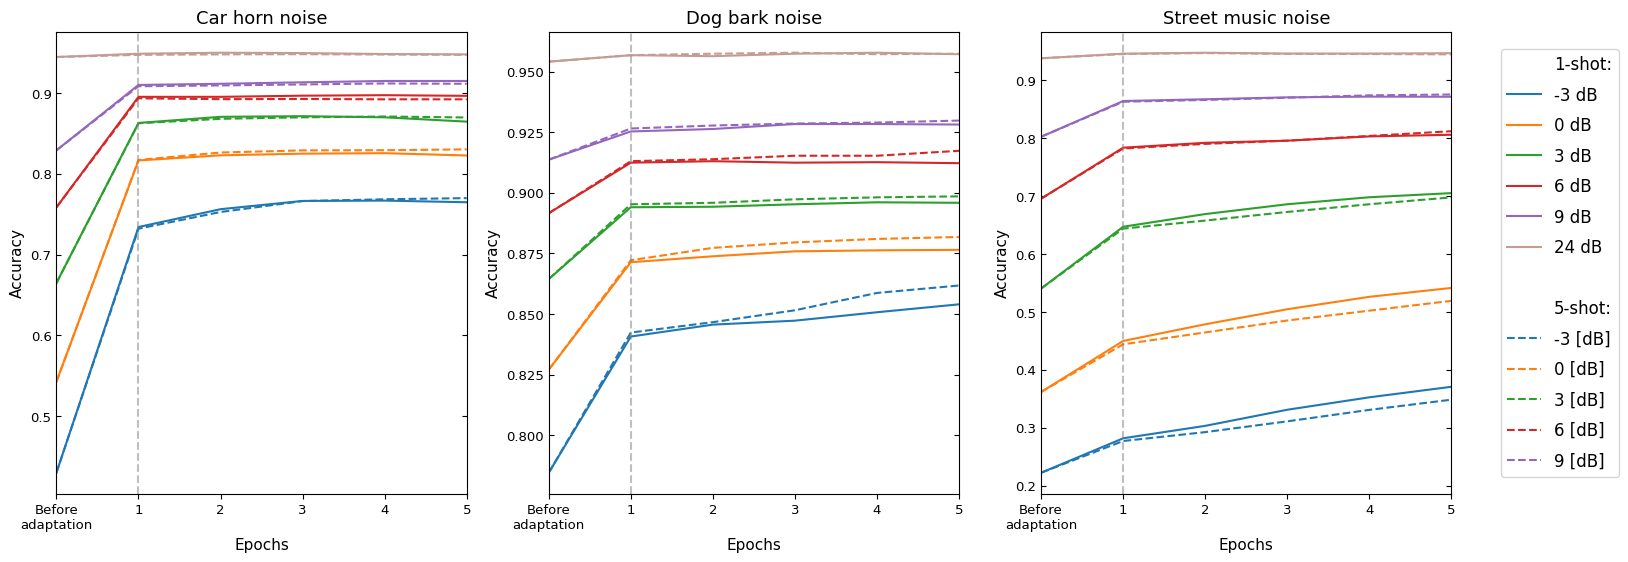

In [ ]:
# plot for the paper
data2=pd.read_csv('./results/few_shot_5.csv')
data1=pd.read_csv('./results/few_shot_1.csv')
df_baseline = pd.read_csv("./results/full_precision_pretrain_specific_noise.csv")
df_baseline = df_baseline.rename(columns={'snr_test': 'snr_train', 'accuracy': 'epochs_0'})

mapping_dict = df_baseline.set_index(['model', 'noise_type', 'snr_train'])['epochs_0'].to_dict()

# Create epochs_0 column in data2 by mapping values from df_baseline
data1['epochs_0'] = data1.apply(lambda row: mapping_dict.get((row['model'], row['noise_type'], row['snr_train'])), axis=1)
data2['epochs_0'] = data2.apply(lambda row: mapping_dict.get((row['model'], row['noise_type'], row['snr_train'])), axis=1)
data1_copy = data1.copy()
data1_copy['dataset'] = 'data1'  
data2_copy = data2.copy()
data2_copy['dataset'] = 'data2'  
combined_data = pd.concat([data1_copy, data2_copy], ignore_index=True)  

models = ['baseline']
model = models[0]
noise_types = combined_data['noise_type'].unique()

fig, axes = plt.subplots(1,3, figsize=(18, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(combined_data['snr_train'].unique())))
size = 13

snr_list = [-3, 0, 3, 6, 9,24]
for i, noise_type in enumerate(noise_types):
    ax = axes[i]
    
    subset1 = data1[(data1['model'] == model) & (data1['noise_type'] == noise_type)]
    subset2 = data2[(data2['model'] == model) & (data2['noise_type'] == noise_type)]
    
    for idx, snr in enumerate(snr_list):
        snr_subset1 = subset1[subset1['snr_train'] == snr]
        epochs = [f'epochs_{k}' for k in range(6)]
        ax.plot([0,1,2,3,4,5], snr_subset1[epochs].values.flatten(), label=f'{snr} dB', color=colors[idx], linestyle='-')
    
    for idx, snr in enumerate(snr_list):
        snr_subset2 = subset2[subset2['snr_train'] == snr]
        epochs = [f'epochs_{k}' for k in range(6)]
        ax.plot([0,1,2,3,4,5], snr_subset2[epochs].values.flatten(), label=f'{snr} [dB]', color=colors[idx], linestyle='--')
    
    ax.set_title(f'{model} - {noise_type}')
    ax.set_xlabel('Epochs',fontsize=size-2)
    ax.set_ylabel('Accuracy',fontsize=size-2)
    
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['Before\nadaptation', '1', '2', '3', '4', '5'])
    ax.set_xlim(0,5)
    
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
    
    ax.tick_params(axis='both', labelsize=size-3.5)
    ax.tick_params(axis='y', right=True, labelright=False,direction='in')
    ax.spines['right'].set_visible(True)

handles, labels = plt.gca().get_legend_handles_labels()
subtitle1 = mpatches.Patch(color='white', alpha=0)

handles.insert(0, subtitle1)
labels.insert(0, '1-shot:')
handles.insert(len(snr_list)+1, subtitle1)
labels.insert(len(snr_list)+1, ' ')
handles.insert(len(snr_list)+2, subtitle1)
labels.insert(len(snr_list)+2, '5-shot:')

reordered_handles = [handles[0], 
            handles[1], 
            handles[2], 
            handles[3], 
            handles[4], 
            handles[5], 
            handles[6],
            handles[7],
            handles[8],
            handles[9],
            handles[10],
            handles[11],
            handles[12],
            handles[13]]
reordered_labels = [labels[0], 
            labels[1], 
            labels[2], 
            labels[3], 
            labels[4],
            labels[5],
            labels[6],
            labels[7],
            labels[8],
            labels[9],
            labels[10],
            labels[11],
            labels[12],
            labels[13]]

plt.legend(reordered_handles, reordered_labels,  loc='center left',
    bbox_to_anchor=(1.1,0.5), 
    ncol=1,
    labelspacing=0.75,
    fontsize=size-1)

axes[0].set_title("Car horn noise",fontsize=size)
axes[1].set_title("Dog bark noise",fontsize=size)
axes[2].set_title("Street music noise",fontsize=size)
plt.subplots_adjust(hspace = 0.25)
plt.show()

if False:
    fig.savefig('./figure/epochs_v2.pdf', dpi=900,bbox_inches='tight')

---------------------------------------------------------------
# Other experiments no included in the paper

## 1- and 5-shots - 5 epochs

This experiment only runs for SNR = -3dB and 24dB (extreme SNR cases).

It is designed for comparing, after 5 epochs, if 5-shots perform better than 1-shot

In [ ]:
# 1-shot
epochs = 5
snr_values = [-3,24]

sub_train_set_waveform_i_samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=1)


batch_lenght=len(sub_train_set_waveform_i_samples_per_class)


one_shot_epochs_5_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:

        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_i_samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models

        continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate = param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate = param.LEARNING_RATE,num_epochs=epochs,show_plot=False)

        #test the model
        for snr_test in param.SNR_VALUES:
            
            test_loader = add_noise_on_set(noise_type,snr_test,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
            
            print("Test Baseline model: " + noise_type + " at " +str(snr_test)+ "dB")
            accuracy = test_model_accuracy(test_loader,baseline_model,device)[0]
            temp_df = pd.DataFrame({
                            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train,
                            "snr_test": snr_test, "accuracy": accuracy},index=[0])
                    
            one_shot_epochs_5_df = pd.concat([one_shot_epochs_5_df ,temp_df], ignore_index=True)

            print("Test Noise-aware model: " + noise_type + " at " +str(snr_test)+ "dB")
            accuracy = test_model_accuracy(test_loader,noise_aware_model,device)[0]

            temp_df = pd.DataFrame({
                            "model": "noise-aware", "noise_type": noise_type, "snr_train": snr_train,
                            "snr_test": snr_test, "accuracy": accuracy},index=[0])
                    
            one_shot_epochs_5_df = pd.concat([one_shot_epochs_5_df ,temp_df], ignore_index=True)

one_shot_epochs_5_df.to_csv("./results/few_shot_1_epochs_5.csv",index=False)

In [ ]:
# 5-shots
epochs = 5
shot =5
snr_values = [-3,24]

sub_train_set_waveform_i_samples_per_class = create_balanced_subset(train_set_waveform, samples_per_class=shot)


batch_lenght=len(sub_train_set_waveform_i_samples_per_class)


five_shot_epochs_5_df = pd.DataFrame()

for noise_type in param.NOISE_TYPES:
    for snr_train in param.SNR_VALUES:

        
        train_loader = add_noise_on_set(noise_type,snr_train,sub_train_set_waveform_i_samples_per_class,device,
                                mel_spectrogram,target="train",suffle=True,
                                batch_size=batch_lenght)
        
        test_loader = add_noise_on_set(noise_type,snr_train,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
        
        # reload the models
        baseline_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        baseline_model.load_state_dict(torch.load("./models/baseline_model.pth",weights_only=True))
        noise_aware_model = ConvNetWithFC(ConvNet().to(device)).to(device)
        noise_aware_model.load_state_dict(torch.load("./models/full_precision_"+str(100)+".pth",weights_only=True))
        
        # active-learning models

        continue_training_model(train_loader, test_loader, baseline_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)
        continue_training_model(train_loader, test_loader, noise_aware_model,device,
                            learning_rate=param.LEARNING_RATE,num_epochs=epochs,show_plot=False)

        #test the model
        for snr_test in param.SNR_VALUES:
            
            test_loader = add_noise_on_set(noise_type,snr_test,test_set_waveform,device,
                                mel_spectrogram,target="train",suffle=False,
                                batch_size=batch_lenght)
            
            print("Test Baseline model: " + noise_type + " at " +str(snr_test)+ "dB")
            accuracy = test_model_accuracy(test_loader,baseline_model,device)[0]
            temp_df = pd.DataFrame({
                            "model": "baseline", "noise_type": noise_type, "snr_train": snr_train,
                            "snr_test": snr_test, "accuracy": accuracy},index=[0])
                    
            five_shot_epochs_5_df = pd.concat([five_shot_epochs_5_df ,temp_df], ignore_index=True)

            print("Test Noise-aware model: " + noise_type + " at " +str(snr_test)+ "dB")
            accuracy = test_model_accuracy(test_loader,noise_aware_model,device)[0]

            temp_df = pd.DataFrame({
                            "model": "noise-aware", "noise_type": noise_type, "snr_train": snr_train,
                            "snr_test": snr_test, "accuracy": accuracy},index=[0])
                    
            five_shot_epochs_5_df = pd.concat([five_shot_epochs_5_df ,temp_df], ignore_index=True)

five_shot_epochs_5_df.to_csv("./results/few_shot_5_epochs_5.csv",index=False)

Test Baseline model: car_horn_background at -3dB
Test Noise-aware model: car_horn_background at -3dB
Test Baseline model: car_horn_background at 24dB
Test Noise-aware model: car_horn_background at 24dB
Test Baseline model: car_horn_background at -3dB
Test Noise-aware model: car_horn_background at -3dB
Test Baseline model: car_horn_background at 24dB
Test Noise-aware model: car_horn_background at 24dB
Test Baseline model: dog_bark_foreground at -3dB
Test Noise-aware model: dog_bark_foreground at -3dB
Test Baseline model: dog_bark_foreground at 24dB
Test Noise-aware model: dog_bark_foreground at 24dB
Test Baseline model: dog_bark_foreground at -3dB
Test Noise-aware model: dog_bark_foreground at -3dB
Test Baseline model: dog_bark_foreground at 24dB
Test Noise-aware model: dog_bark_foreground at 24dB
Test Baseline model: street_music_foreground at -3dB
Test Noise-aware model: street_music_foreground at -3dB
Test Baseline model: street_music_foreground at 24dB
Test Noise-aware model: street

In [ ]:
def plot_active_learning_performance(df_baseline, df_few_shot, title):
    
    # Get unique noise types
    noise_types = df_baseline['noise_type'].unique()
    
    # Filter the dataframes for each model
    df_baseline_baseline = df_baseline[df_baseline['model'] == 'baseline']
    df_few_shot_baseline = df_few_shot[df_few_shot['model'] == 'baseline']
    
    df_baseline_noise_aware = df_baseline[df_baseline['model'] == 'noise_aware']
    df_few_shot_noise_aware = df_few_shot[df_few_shot['model'] == 'noise-aware']
    
    # Iterate over each noise type
    for noise_type in param.NOISE_TYPES:
        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        
        # SUBPLOT 1: Baseline model
        # Plot baseline data (black line)
        baseline_data = df_baseline_baseline[df_baseline_baseline['noise_type'] == noise_type]
        ax1.plot(baseline_data['snr_test'], baseline_data['accuracy'], 'k-', label='Baseline', linewidth=2)
        
        # Plot few-shot data for baseline model
        few_shot_data = df_few_shot_baseline[df_few_shot_baseline['noise_type'] == noise_type]
        snr_train_values = few_shot_data['snr_train'].unique()
        
        for snr_train in snr_train_values:
            subset = few_shot_data[few_shot_data['snr_train'] == snr_train]
            ax1.plot(subset['snr_test'], subset['accuracy'], label=f'snr_train={snr_train}', alpha=0.6)
        
        # Add labels, title, and legend for subplot 1
        ax1.invert_xaxis()
        ax1.set_xlabel('SNR Test')
        ax1.set_ylabel('Accuracy')
        ax1.set_title(f'Baseline model vs. few-shot\nNoise Type: {noise_type}')
        ax1.legend()
        ax1.grid(True)
        
        # SUBPLOT 2: Noise-aware model
        # Plot baseline data (black line)
        baseline_data = df_baseline_noise_aware[df_baseline_noise_aware['noise_type'] == noise_type]
        ax2.plot(baseline_data['snr_test'], baseline_data['accuracy'], 'k-', label='Noise-aware Baseline', linewidth=2)
        
        # Plot few-shot data for noise aware model
        few_shot_data = df_few_shot_noise_aware[df_few_shot_noise_aware['noise_type'] == noise_type]
        snr_train_values = few_shot_data['snr_train'].unique()
        
        for snr_train in snr_train_values:
            subset = few_shot_data[few_shot_data['snr_train'] == snr_train]
            ax2.plot(subset['snr_test'], subset['accuracy'], label=f'snr_train={snr_train}', alpha=0.6)
        
        # Add labels, title, and legend for subplot 2
        ax2.invert_xaxis()
        ax2.set_xlabel('SNR Test')
        ax2.set_ylabel('Accuracy')
        ax2.set_title(f'Noise-aware model vs. few-shot\nNoise Type: {noise_type}')
        ax2.legend()
        ax2.grid(True)
        
        # Add a main title for the entire figure
        fig.suptitle(title, fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust rect to make room for suptitle
        plt.show()

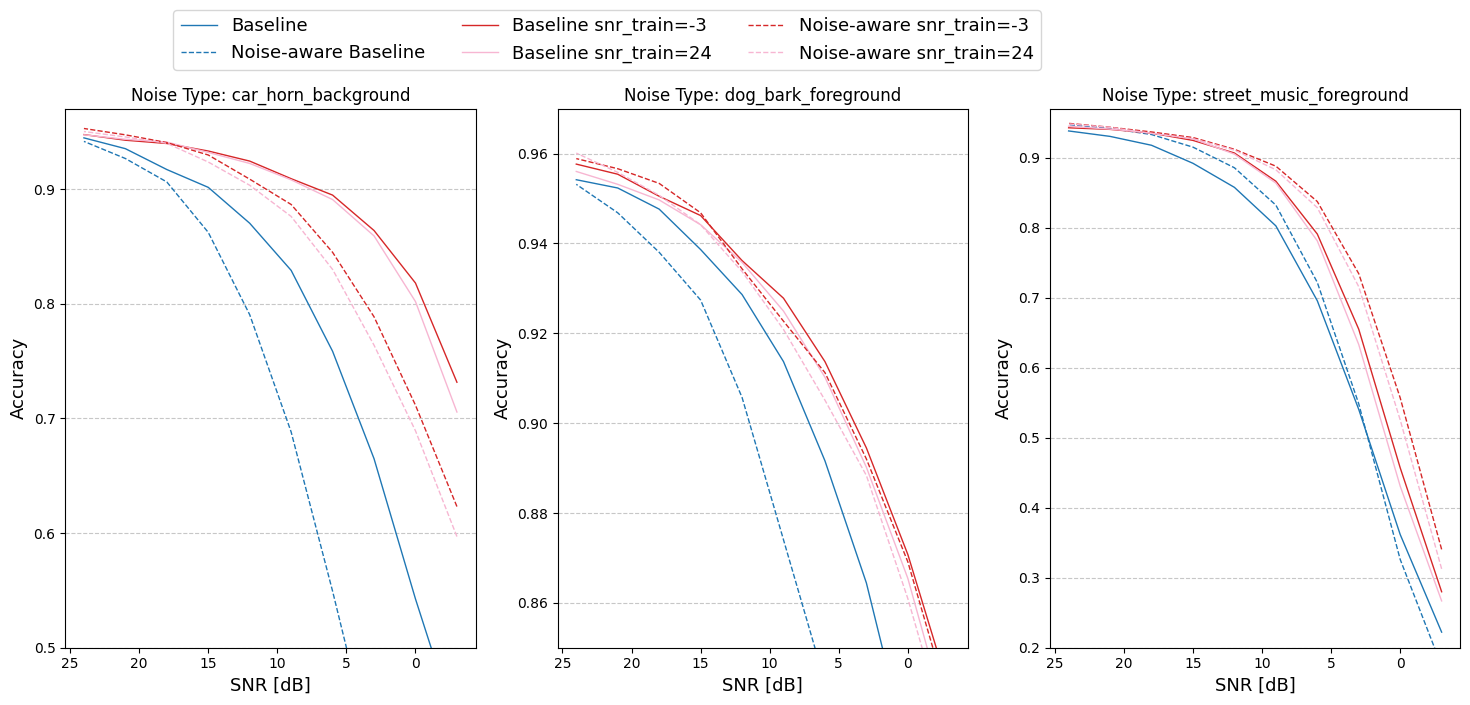

In [ ]:
df = pd.read_csv("./results/few_shot_5_epochs_1.csv")
pretrained_specific_noise_df = pd.read_csv("./results/full_precision_pretrain_specific_noise.csv")
plot_active_learning_performance(pretrained_specific_noise_df, df, 
                                title="5 epochs - 1-shot")